# LuisaViaRoma Reviews Analysis: from Bag of Words to LLMs

## 📌 Executive Summary

**Business problem.** A luxury e-commerce brand (LuisaViaRoma) receives thousands of text reviews on Trustpilot: reading them manually to understand what's not working in the customer experience doesn't scale.

**What I did.** I collected ~10,000 real reviews via web scraping (Selenium), translated and cleaned them, and compared 6 sentiment analysis approaches — from a rule-based baseline (VADER), to classic ML models on TF-IDF (Naive Bayes, Decision Tree, Random Forest, SVM), up to fine-tuning a BERT model — alongside a latent topic analysis with Topic Modeling (LDA).

**Key result.** Fine-tuning BERT raises the Macro F1-Score from 0.56 (VADER baseline) to 0.73, with the sharpest improvement precisely on the hardest class to detect — **Neutral** reviews (Recall: 4% → 39%), the ones that hide the subtlest, most business-relevant issues.

**Potential impact.** A system like this would let a company automate customer experience monitoring and prioritize real complaints, catching dissatisfaction even where the star rating doesn't make it obvious.

*Skills demonstrated: web scraping (Selenium), end-to-end NLP (preprocessing, TF-IDF, topic modeling), Transformer model fine-tuning (HuggingFace), methodologically rigorous model comparison.*

---

## Introduction

## Dataset Acquisition via Web Scraping
The initial phase of the project involved collecting the text corpus directly from the Trustpilot platform, focusing on reviews of the luxury e-commerce brand LuisaViaRoma.

To ensure structured data acquisition, a Web Scraping script based on the Selenium library was implemented. Selenium was chosen over static parsers because of the need to interact with the page's dynamic Document Object Model (DOM), which requires handling JavaScript elements (such as multi-page navigation or expanding truncated text).

The extraction produced a dataframe containing the core metadata needed for the subsequent analysis.

## Dataset Structure
The scraping process populated a tabular data structure, whose main features are described by the following variables:

- **Name**: identifier of the review's author.

- **Date**: timestamp of when the feedback was submitted.

- **Stars**: discrete value (rating from 1 to 5) representing the polarity assigned by the user. This will be the target variable for the classification stages.

- **Location**: geographic information (Country) declared by the user.

- **Review Text**: the unstructured text body containing the purchase experience. This is the primary corpus on which Natural Language Processing techniques will be applied.

## Language Standardization
Since LuisaViaRoma is a brand with an international audience, the original dataset showed high linguistic variance across reviews. A multilingual corpus is a significant complicating factor for building a coherent vector space and for effectively applying Text Classification models.

To mitigate the spurious dimensionality caused by a multilingual vocabulary, and to ensure the effectiveness of the later tokenization and lemmatization steps, a Machine Translation process was implemented.

The raw dataframe was processed through a dedicated script that, interfacing with the Google Translator API, bulk-translated every string in the *Testo_Recensione* column, forcing **English** as the output language.

This operation achieved:

1. **Corpus Standardization**: convergence of all documents into a single lingua franca.

2. **Preprocessing Optimization**: the ability to use stop-word vocabularies and pre-trained models (or NLP libraries) highly optimized for English.

## Data Ingestion and Preliminary Inspection
Following the scraping and language-standardization steps, the consolidated dataset was imported into the development environment to proceed with the Data Validation and Text Mining stages.

In [1]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#load the dataset
df=pd.read_csv('data/recensioni_luisaviaroma_tradotte.csv', sep=';')

#drop the Nome column: not needed for the analysis, and it's real personal data
#(names of the review authors) that shouldn't be published in a public repo
df = df.drop(columns=['Nome'])

print(f'Dataframe shape (rows x columns): {df.shape}')

Dataframe shape (rows x columns): (10099, 4)


In [2]:
print(f'Missing values per column:\n {df.isnull().sum()}')

Missing values per column:
 Data                0
Stelle              0
Localizzazione      0
Testo_Recensione    0
dtype: int64


There are no missing values, because when the reviews were extracted during Scraping, reviews with no text were skipped — i.e. those where users expressed their judgment only through the star rating.

*Why?* Because the purpose of this work is to analyze the text of the reviews.

In [3]:
df.head()

,Data,Stelle,Localizzazione,Testo_Recensione
0,2026-04-03T04:11:19.000Z,5,FR,Best app for fashion.
1,2026-03-10T22:28:43.000Z,1,AE,I have been a customer with Luisaviaroma for a...
2,2026-03-04T15:22:26.000Z,5,IT,Fantastic Shop
3,2026-02-22T20:10:28.000Z,5,CO,Very good I like it
4,2026-02-22T00:44:23.000Z,5,IT,"Top, easy to use"


## Exploratory Data Analysis
The exploratory analysis phase started with a chart showing the monthly time distribution of reviews published on Trustpilot, covering the period from 2011 to early 2026.

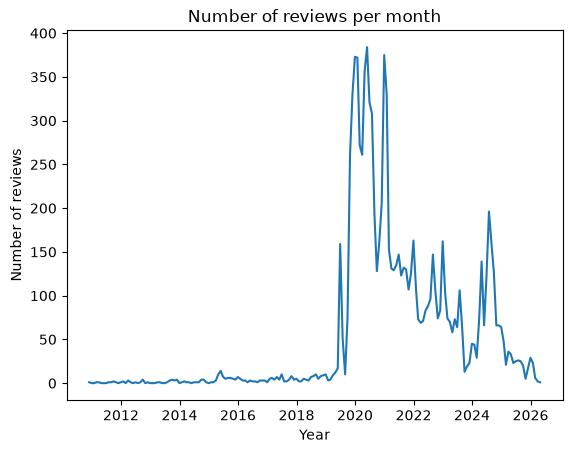

In [4]:
import matplotlib.pyplot as plt
df['Data']=pd.to_datetime(df['Data'])
df=df.set_index('Data')

plt.plot(df['Testo_Recensione'].resample('ME').count())
plt.xlabel('Year')
plt.ylabel('Number of reviews')
plt.title('Number of reviews per month')
plt.show()

The time-series analysis reveals three distinct phases, key to understanding user engagement dynamics:
- **Latency Phase (2011 - 2019)**: over this long stretch, the volume of reviews is marginal and roughly constant, close to zero. This suggests that during this period Trustpilot wasn't the main review channel used (founded in 2007 but only gaining real traction after 2015).

- **Adoption Peak and Expansion (2020 - 2022)**: a structural break appears in the time series around the end of 2019/start of 2020, with a spike bringing volume close to 400 reviews per month. This exponential growth is likely attributable to the global e-commerce boom during the pandemic period.

- **Settling and Volatility Phase (2023 - 2026)**: after the two-year peak-expansion period, volumes show a declining trend but with high volatility. Isolated spikes stand out (e.g. mid-2024, close to 200 reviews), which could coincide with specific commercial events (seasonal sales, Black Friday) or with widespread logistics issues that pushed users to share their experience. In the most recent months analyzed, volume tends to stabilize at lower values.

Looking at this time distribution calls for some methodological choices in the subsequent Natural Language Processing (NLP) stages:
- **Sampling and Balancing**: since the vast majority of the text corpus is concentrated in the post-2019 period, Topic Modeling algorithms (like LDA) and the classifiers will inevitably reflect the language, products and logistics dynamics of this specific period.

- **Noise Handling**: it could be worth excluding reviews before 2019 from the training dataset. The small volumes from those years don't provide a sufficient statistical base and risk introducing noise without adding predictive value to the classification model.

Next, the distribution of reviews was analyzed as a function of the score assigned by users, the Stars:

Star distribution: Stelle
5    7284
1    1148
4     951
3     424
2     292
Name: count, dtype: int64


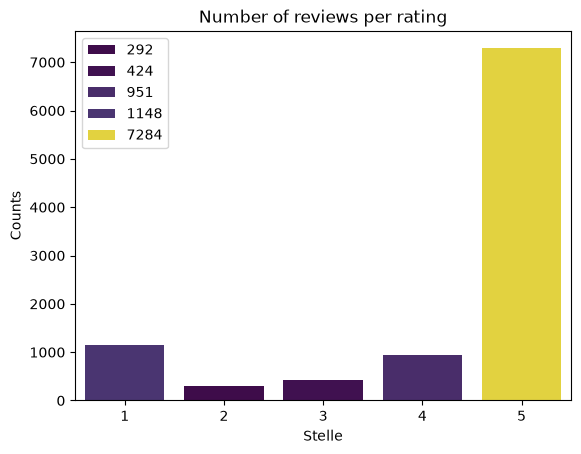

In [5]:
import seaborn as sns

star=df['Stelle'].value_counts()
print(f'Star distribution: {star}')
ax=sns.barplot(x=star.index, y=star.values, hue=star.values, palette='viridis', legend=True)
ax.set(ylabel='Counts')
plt.title('Number of reviews per rating')
plt.show()

The bar chart shows:
- The distribution is markedly skewed, overwhelmingly dominated by the "5 stars" class, which accounts for the vast majority of observations (7,284 reviews).

- The pattern observed mirrors the typical *J-shaped curve* seen in the literature on online reviews. Users tend to leave feedback mostly for extreme experiences: excellent ratings (5 stars) or, secondarily, strongly negative experiences (1 star, 1,148 reviews). Neutral or mediocre experiences (2 and 3 stars) generate significantly less engagement, making them the least represented classes (292 and 424 occurrences respectively).

- From a strictly business-oriented perspective, the overwhelming prevalence of 4- and 5-star reviews confirms an overall very high level of Customer Satisfaction for the LuisaViaRoma brand, while also highlighting a non-negligible cohort of deeply dissatisfied customers (1 star) whose motivations will require deeper semantic investigation (Topic Modeling).

This configuration of the data required careful methodological thinking ahead of building the predictive models.

Since the dataset is severely imbalanced, directly training a supervised classifier (e.g. Logistic Regression applied to the Bag-of-Words matrix) on this "raw" data would push the model toward a strong bias toward the majority class — i.e. the algorithm would tend to classify almost every text as "5 stars", achieving high overall Accuracy but disastrous Precision and Recall on the minority classes, which would essentially be treated as "statistical noise".

Next, the length of the review text was analyzed.

To do this, new metrics first need to be derived from the review-text column; it's common practice to compute both the number of characters and the number of words.

In [6]:
df['conteggio parole']=df['Testo_Recensione'].apply(lambda x: len(str(x).split()))
df['conteggio caratteri']=df['Testo_Recensione'].apply(lambda x: len(str(x)))

In customer-care text mining it's often observed that 1-star reviews (complaints) are significantly longer and more detailed than 5-star reviews (concise praise like "Everything perfect").

The most suitable chart to visualize this relationship is the Boxplot, since it shows the median, the spread, and — most importantly — outliers.

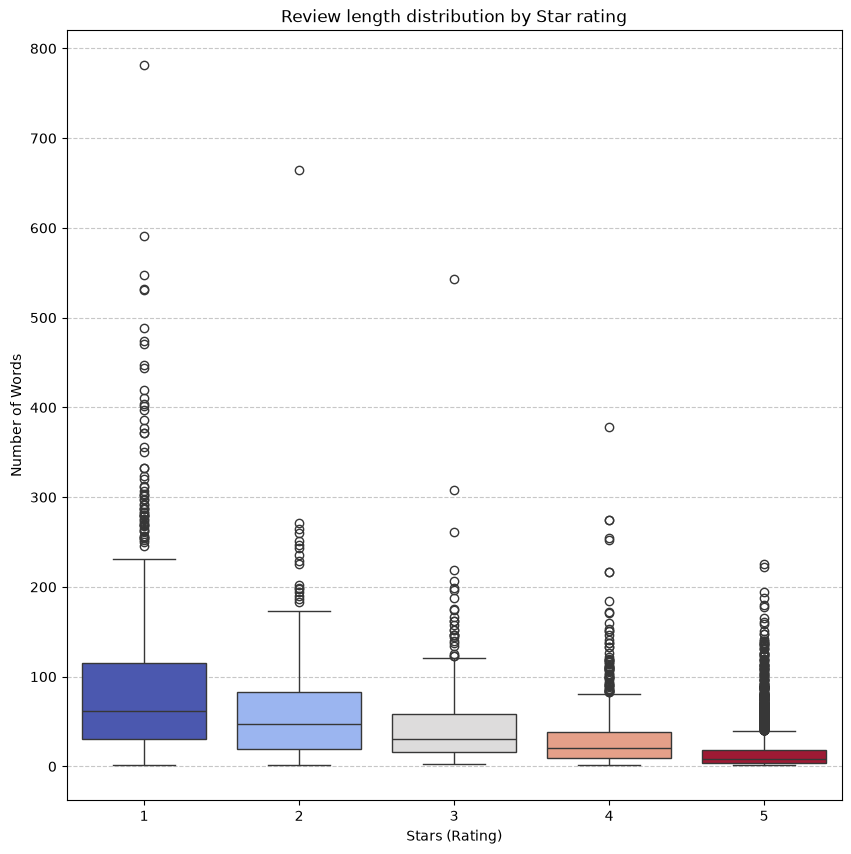

In [7]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df, x='Stelle', y='conteggio parole', hue='Stelle', palette='coolwarm', legend=False)
plt.title('Review length distribution by Star rating')
plt.xlabel('Stars (Rating)')
plt.ylabel('Number of Words')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

A clear inverse relationship is observed between user satisfaction level and review length: 1-star ratings show the highest median and the widest interquartile range (the size of the box, which captures the central 50% of observations). Moving toward higher scores, both the median length and the variance of the data shrink progressively and drastically.

The 1-star class shows a pronounced upper tail of outliers, with reviews reaching an exceptional length of nearly 800 words.

In contrast, the distribution for 5-star reviews is extremely compressed: the vast majority of texts sit below 30 words, and even the extreme values rarely exceed the 200-word threshold.

This pattern empirically confirms the typical *venting* effect seen on review platforms: a strongly negative experience (e.g. issues with returns, poor customer service, or logistics delays) pushes the user to write long, detailed, context-rich accounts; conversely, excellent service (5 stars) is experienced as a confirmation of expectations and is typically expressed through short, concise formulas ("Perfect", "Super fast shipping", "Great purchase").

This strong structural imbalance in document length raises specific technical challenges for the subsequent preprocessing and modeling stages:
- **Feature Weighting (TF-IDF vs. BoW)**: since documents with negative sentiment contain a markedly larger volume of text, using a Bag-of-Words matrix based on raw absolute frequencies (*Term Frequency*) would risk over-weighting terms found in the longer texts. For this reason, TF-IDF vectorization (*Term Frequency-Inverse Document Frequency*) will be used going forward, since it applies a penalty based on document frequency and normalizes the weights, mitigating the length-driven distortion.

- **Topic Modeling (LDA)**: the longer texts (1- and 2-star reviews) will provide a corpus with richer vocabulary and more articulated semantic context, making it easier and more effective to extract well-defined, coherent "topics" from the complaints. Conversely, the extreme brevity of 5-star reviews could make extracting latent topics via LDA statistically more challenging, requiring careful parameter tuning to avoid generating generic or meaningless clusters.

Using the location column, it's possible to isolate the impact of geography on how the service offered by LuisaViaRoma is perceived:

In [8]:
tot_locations=df['Localizzazione'].value_counts()
print(tot_locations)

Localizzazione
IT    4029
DE     654
GB     596
FR     522
US     519
      ... 
CD       1
TG       1
SN       1
VA       1
IM       1
Name: count, Length: 107, dtype: int64


There are 107 locations in total, but the chart would be overcrowded, so only the top 20 locations were extracted.

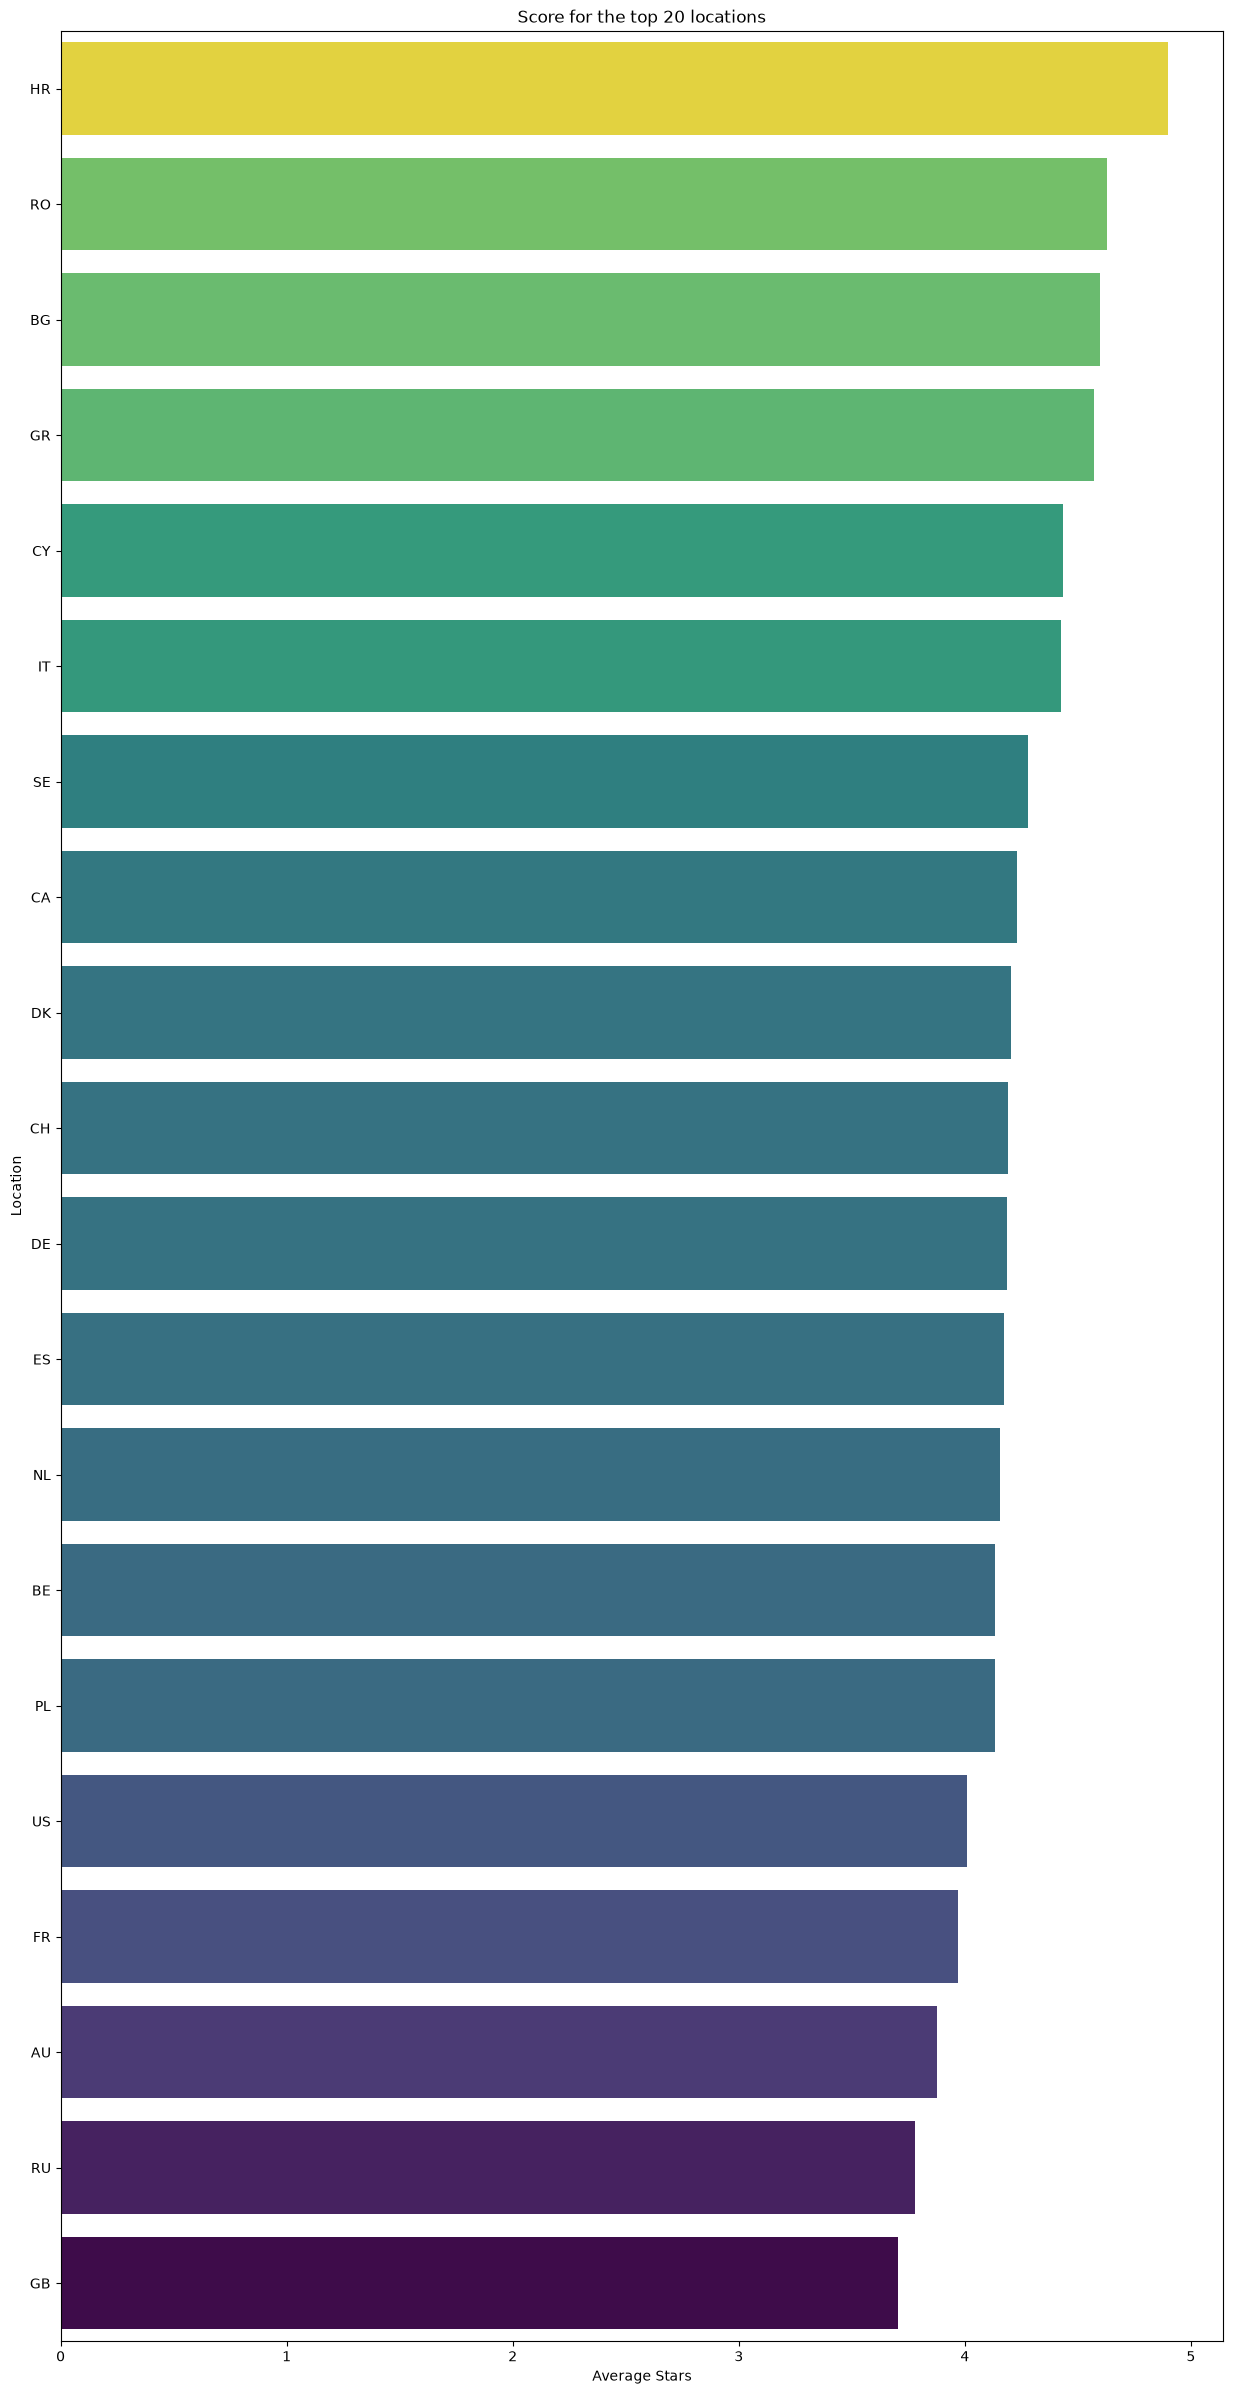

In [9]:
top_locations=tot_locations.head(20).index

df_top_loc=df[df['Localizzazione'].isin(top_locations)]
media_stelle_loc=df_top_loc.groupby('Localizzazione')['Stelle'].mean().sort_values(ascending=False)

plt.figure(figsize=(15,30))
sns.barplot(x=media_stelle_loc.values, y=media_stelle_loc.index, hue=media_stelle_loc.values, palette='viridis', legend=False)
plt.title('Score for the top 20 locations')
plt.xlabel('Average Stars')
plt.ylabel('Location')
plt.show()

The horizontal bar chart shows the average user satisfaction, measured in stars, broken down by the 20 geographic areas (ISO country codes) with the highest review volume.

The top of the chart is dominated by countries such as Croatia (HR), Romania (RO), Bulgaria (BG) and Greece (GR); in particular, the Croatian market shows an exceptionally high average score, close to the maximum value of 5. This may suggest extremely efficient logistics to these destinations, or brand positioning that perfectly matches the expectations of that customer base.

Italy (IT) sits consistently in the medium-high tier, with a strongly positive average rating (around 4.4-4.5). Being the company's domestic market, this reinforces the assumption of generally high satisfaction among Italian customers.

The UK ranking last (with an approximate average of 3.7 stars) is a highly specific warning sign.

The clear gap between the performance of European (or nearby) countries and non-EU countries (or countries with complex customs contexts, like the post-Brexit UK) suggests that the drivers of lower satisfaction in these areas may not be related to product quality itself, but to exogenous factors. Among the most likely causes (especially after randomly reviewing a few reviews in the dataset) are:
- Extended shipping times for intercontinental routes.
- Complex or costly returns handling for international customers.
- Unexpected customs duties and import taxes.

To focus on the countries with the biggest issues, the perspective of the previous analysis needs to be flipped.

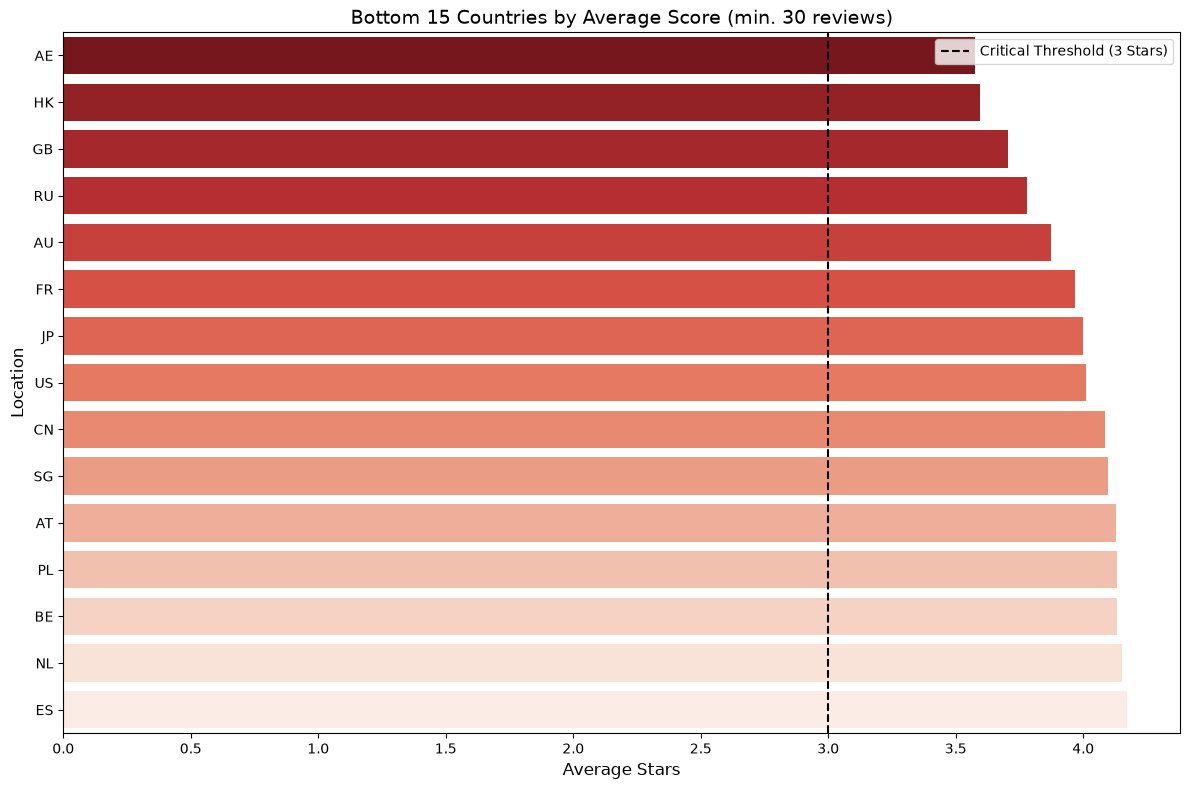

In [10]:


# 1. Set a minimum review count to ensure statistical relevance
min_threshold = 30 

# 2. Count reviews per Country
count_per_country = df['Localizzazione'].value_counts()

# 3. Keep only Countries above the minimum threshold
valid_countries = count_per_country[count_per_country >= min_threshold].index

# 4. Build a subset of the dataframe with the filtered Countries
df_valid = df[df['Localizzazione'].isin(valid_countries)]

# 5. Compute the mean star rating, sorted ascending (worst to best)
worst_countries = df_valid.groupby('Localizzazione')['Stelle'].mean().sort_values(ascending=True)

# 6. Select the 10-15 countries with the lowest score
bottom_15_countries = worst_countries.head(15)

# Chart
plt.figure(figsize=(12, 8))
# Use a color palette that emphasizes the critical areas (e.g. shades of red)
sns.barplot(x=bottom_15_countries.values, y=bottom_15_countries.index, palette='Reds_r', hue=bottom_15_countries.index, legend=False)

plt.title(f'Bottom 15 Countries by Average Score (min. {min_threshold} reviews)', fontsize=14)
plt.xlabel('Average Stars', fontsize=12)
plt.ylabel('Location', fontsize=12)

# Add a vertical line to highlight the critical threshold (e.g. 3 stars)
plt.axvline(x=3.0, color='black', linestyle='--', label='Critical Threshold (3 Stars)')
plt.legend()
plt.tight_layout()
plt.show()

The most notable macro-level finding is that no market falls below the critical 3-star threshold; even the area with the lowest average rating (United Arab Emirates - AE) sits above a 3.5 score, showing that LuisaViaRoma isn't failing outright in any established market.

Looking at the top of the chart (i.e. the worst scores overall), a clear geographic pattern emerges. The five lowest-scoring countries all belong to non-EU contexts or contexts with specific import regimes: United Arab Emirates (AE), Hong Kong (HK), United Kingdom (GB), Russia (RU) and Australia (AU).

This geographic heterogeneity will inform some choices in the later stages of the analysis.

After analyzing review volume over time, review quality over time was also analyzed — useful for spotting any "crises" (such as issues tied to a specific period, e.g. the Christmas season).

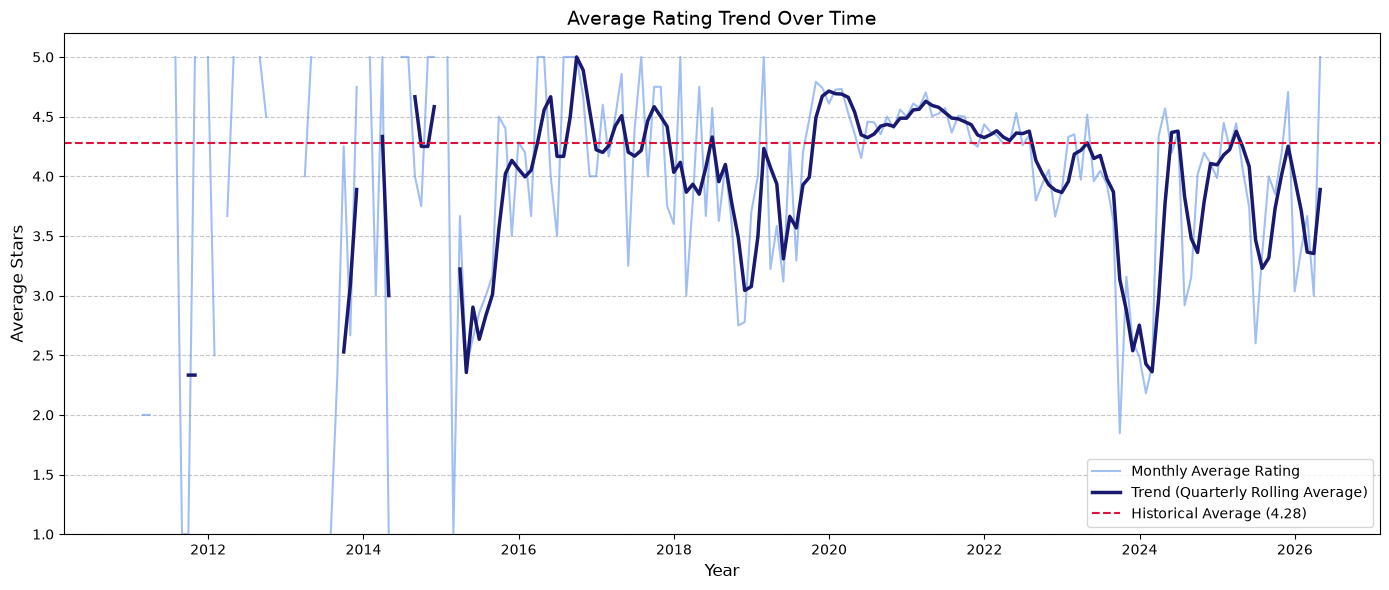

In [11]:
media_mensile = df['Stelle'].resample('ME').mean()

#quarterly (3-month) rolling average to highlight the trend
media_mobile = media_mensile.rolling(window=3).mean()

# Build the chart
plt.figure(figsize=(14, 6))

# Plot the monthly average (lighter/thinner, to show volatility)
plt.plot(media_mensile.index, media_mensile.values, 
         label='Monthly Average Rating', color='cornflowerblue', alpha=0.6, linewidth=1.5)

# Plot the rolling average (bolder, to highlight the trend)
plt.plot(media_mobile.index, media_mobile.values, 
         label='Trend (Quarterly Rolling Average)', color='midnightblue', linewidth=2.5)

# Add a reference line for the overall historical average
media_storica = df['Stelle'].mean()
plt.axhline(y=media_storica, color='crimson', linestyle='--', 
            label=f'Historical Average ({media_storica:.2f})')

plt.title('Average Rating Trend Over Time', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Stars', fontsize=12)
plt.ylim(1, 5.2) # Set Y-axis limits based on the star scale
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The chart reveals three distinct macro-phases in how the brand's quality was perceived:

- **High Volatility and Statistical Noise (2012 - 2019)**: in this first phase, the curve shows extreme, fragmented oscillations, with the monthly score frequently bouncing between the two extremes (1.0 and 5.0). This isn't actual service instability, but a statistical artifact: review volumes were close to zero, making the monthly average extremely sensitive to a single piece of feedback (outlier).

- **Stabilization and "Golden Era" (2020 - mid-2023)**: alongside the volume boom documented earlier, there's a sharp drop in volatility. The quarterly rolling average stabilizes consistently above the historical mean, fluctuating in an excellent range between 4.3 and 4.7. This confirms that the platform's large-scale adoption reached a globally very satisfied customer base, naturally "diluting" the weight of negative venting reviews.

- **The "Structural Break" (Late 2023 - 2024)**: the most critical finding occurs around late 2023/early 2024, when the trend collapses vertically, with the rolling average plunging as low as 2.3 stars, dragged down by monthly averages below 2.0. Even in the following two years (2024-2026), despite partial recoveries, the trend remains heavily compromised, chronically running below the historical 4.28 threshold, with marked dips (e.g. mid-2025).

Since data before 2019 is too sparse and extremely volatile, keeping it in the text corpus would risk introducing significant statistical "background noise", hurting the performance of the later topic-extraction (LDA) and classification algorithms.

The dataset is therefore filtered accordingly:

In [12]:
# Print the dataset size BEFORE trimming
print(f"Original Dataset Size: {df.shape[0]} reviews")

# Filtering: keep only records from January 1st, 2019 onward
df = df.sort_index()
df_filtrato = df.loc['2019-01-01':]

# Print the dataset size AFTER trimming
print(f"Filtered Dataset Size (Post-2018): {df_filtrato.shape[0]} reviews")
print(f"Reviews removed: {df.shape[0] - df_filtrato.shape[0]}")

# For convenience, reassign df_filtrato to df to proceed with the next steps
df = df_filtrato.copy()

Original Dataset Size: 10099 reviews
Filtered Dataset Size (Post-2018): 9810 reviews
Reviews removed: 289


To profile the drivers of Customer Satisfaction in a granular way, the dataset was split by the target variable (Sentiment *Positive*, *Neutral* and *Negative*).


Class distribution:
Sentiment
Positive    8038
Negative    1365
Neutral      407
Name: count, dtype: int64


<Axes: ylabel='Sentiment'>

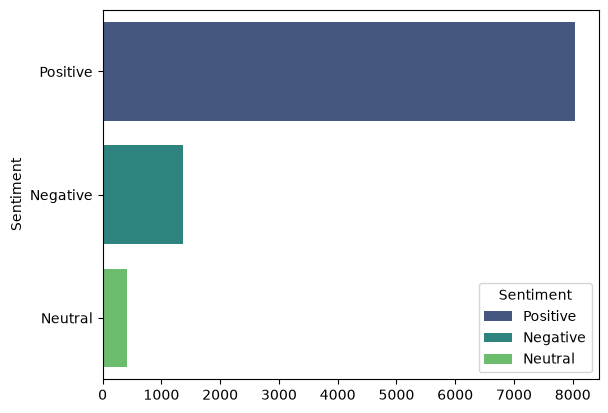

In [13]:
#sentiment mapping
def sentiment(stars):
    if stars>=4 :
        return 'Positive'
    elif stars==3:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentiment']=df['Stelle'].apply(sentiment)
print('\nClass distribution:')
distr=df['Sentiment'].value_counts()
print(distr)

import seaborn as sns
sns.barplot(x=distr.values, y=distr.index, hue=distr.index, palette='viridis', legend=True)

## Pre-Processing

The goal of this phase is to turn raw, unstructured text into a normalized, mathematically interpretable format, stripped of any semantic noise that doesn't add informational value for the predictive models.

First, since the dataset extracted from scraping was then machine-translated, we check whether that translation process failed anywhere and remove the "junk":

In [14]:
from langdetect import detect, DetectorFactory
import langdetect

# Setting a seed ensures langdetect's stochastic algorithm returns reproducible results on every run
DetectorFactory.seed = 0 

def verifica_lingua_inglese(testo):
    """
    Detects the language of a text string.
    Returns the ISO language code, or 'unknown' on error.
    """
    try:
        # Sanity check: the text must be a non-null string 
        # and long enough to allow detection
        if not isinstance(testo, str) or len(testo.strip()) < 3:
            return 'unknown'
            
        return detect(testo)
        
    except langdetect.lang_detect_exception.LangDetectException:
        # Catch exceptions raised by text with no alphabetic characters
        return 'unknown'

# 1. Create a temporary column with the detected language
colonna_testo = 'Testo_Recensione' 
df['Lingua_Rilevata'] = df[colonna_testo].apply(verifica_lingua_inglese)

# 2. Extract descriptive statistics before cleaning
totale_iniziale = df.shape[0]
distribuzione_lingue = df['Lingua_Rilevata'].value_counts()

print("--- Language Detection Statistics ---")
print("Top 5 languages detected in the corpus:")
print(distribuzione_lingue.head(5))
print("-" * 40)

# 3. Filtering: keep only English-language documents
df_pulito = df[df['Lingua_Rilevata'] == 'en'].copy()

# 4. Final report
totale_finale = df_pulito.shape[0]
recensioni_eliminate = totale_iniziale - totale_finale

print(f"Dataset size before filtering: {totale_iniziale} reviews")
print(f"Dataset size after filtering : {totale_finale} reviews")
print(f"Reviews removed (failed translations or invalid text): {recensioni_eliminate}")

# 5. Remove the temporary column to keep the dataframe clean
df = df_pulito.drop(columns=['Lingua_Rilevata'])

--- Language Detection Statistics ---
Top 5 languages detected in the corpus:
Lingua_Rilevata
en    9003
ca     181
fr     168
ro      95
it      65
Name: count, dtype: int64
----------------------------------------
Dataset size before filtering: 9810 reviews
Dataset size after filtering : 9003 reviews
Reviews removed (failed translations or invalid text): 807


After filtering, the classic text Pre-Processing pipeline was applied:

1. **Lowercasing**: converting the whole corpus to lowercase — essential so the algorithm doesn't interpret identical words with different capitalization (e.g. "Shipping" and "shipping") as two distinct semantic entities.

2. **Data Cleansing via Regular Expressions (RegEx)**: systematic removal of URLs, email addresses, HTML tags, punctuation, special symbols, emoji and any numeric digits.

3. **Tokenization**: breaking down each review into atomic units called "tokens" (in most cases, individual words).

4. **Stop-Word Removal**: removing empty words or logical connectors (e.g. articles, prepositions, conjunctions like "the", "of", "that", "and") that occur very frequently but carry no discriminative power for topic detection (LDA) or classification.

5. **Lemmatization or Stemming**: reduces each token to its base or dictionary form (the "lemma"), or bluntly chops off the end of the word, respectively.

In [15]:
#Pre-Processing
import seaborn as sns
from collections import Counter

def ispezione_iniziale(text):
    text=str(text).lower() #normalization
    text=re.sub(r'[^a-z\s]', '', text) #remove punctuation, special characters and numbers
    tokens=text.split() #tokenization
    return tokens

#extract all tokens
all_tokens1=[]
for text in df['Testo_Recensione']:
    all_tokens1.extend(ispezione_iniziale(text))

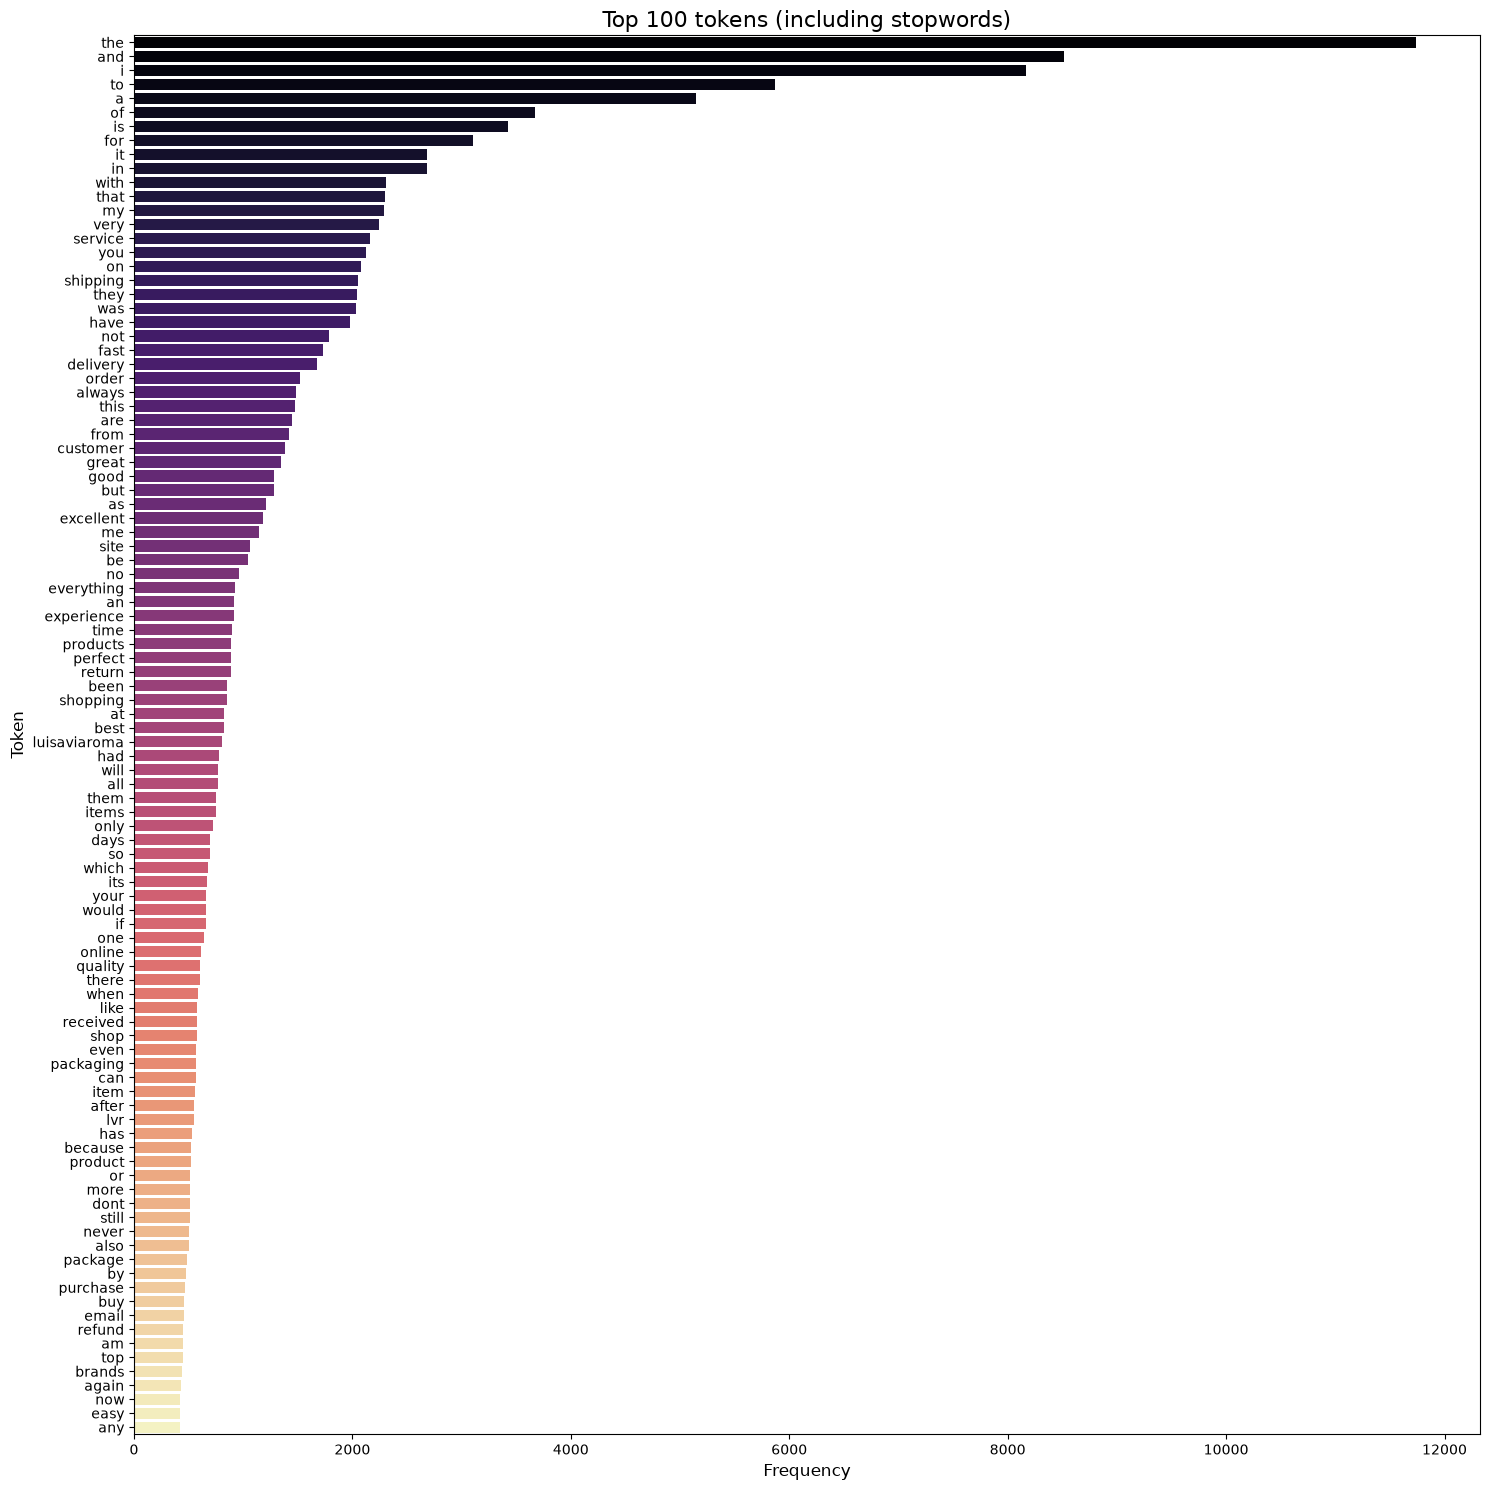

In [16]:
#compute frequencies
token_counts1=Counter(all_tokens1)
top_tokens1=token_counts1.most_common(100)
df_tokens1=pd.DataFrame(top_tokens1, columns=['Token','Frequency'])


#chart
plt.figure(figsize=(15,15))
sns.barplot(x='Frequency', y='Token', data=df_tokens1, palette='magma', hue='Token')
plt.title('Top 100 tokens (including stopwords)', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Token', fontsize=12)
plt.tight_layout()
plt.show()






The horizontal bar chart shows the 100 most frequent terms in the review corpus.

Analyzing this distribution reveals three fundamental macro-dynamics for the subsequent Text Mining stages:

- As expected in computational linguistics, the top spots are overwhelmingly dominated by articles, conjunctions and prepositions ("the", "and", "i", "to", "a", "of"). While these terms form the grammatical backbone of sentences, they carry no intrinsic meaning tied to the brand or the purchase experience, confirming the need to remove them later for Bag-of-Words (BoW) models and for Topic Modeling (LDA).

- The choice of a conservative preprocessing approach is fully justified empirically by the ranking of negation adverbs and adversative conjunctions. Terms like "not", "but" and "no" sit firmly near the top of the ranking. Their high frequency shows that users often use complex constructs or polarity flips (e.g. "good, but...", or "not fast"). Prematurely removing these tokens would have irreparably hurt the accuracy of the later stages.

- Despite the "background noise" generated by stop-words, the nouns and adjectives that manage to climb the ranking already clearly outline the central topics of the reviews; in particular, two main threads emerge:
    1. **The Logistics and Service Area**: words like "service", "shipping", "delivery", "order", "return", "packaging" and "refund" show that the post-purchase experience and parcel handling are the main drivers of the reviews.

    2. **Positive Polarity**: adjectives such as "great", "good", "excellent", "perfect" and "best" show very high frequencies, consistent with the strong skew toward 5-star reviews already observed in the earlier metadata analysis.

To empirically validate the impact of stop-words and determine which lexical constructs actually drive review polarity, a decision-tree-based model (Random Forest Classifier) was trained; this architecture was used not for predictive purposes as such, but as a *Feature Selection* and semantic inspection tool.

The process involved the following analytical steps:

- **TF-IDF Vectorization (Term Frequency-Inverse Document Frequency)**

- **Context Capture (N-grams)**: the algorithm was fed not only single words (unigrams) but also pairs of adjacent words (bigrams). This is essential to catch shifts in semantic valence, capturing key expressions such as "not received", "customer service", or "very bad", which would otherwise be split apart and lose their original meaning.

- **Gini Importance Calculation**: the Random Forest algorithm quantifies the importance of each feature (in this case, the token or bigram) by measuring the average reduction in Gini impurity across all the trees in the forest.

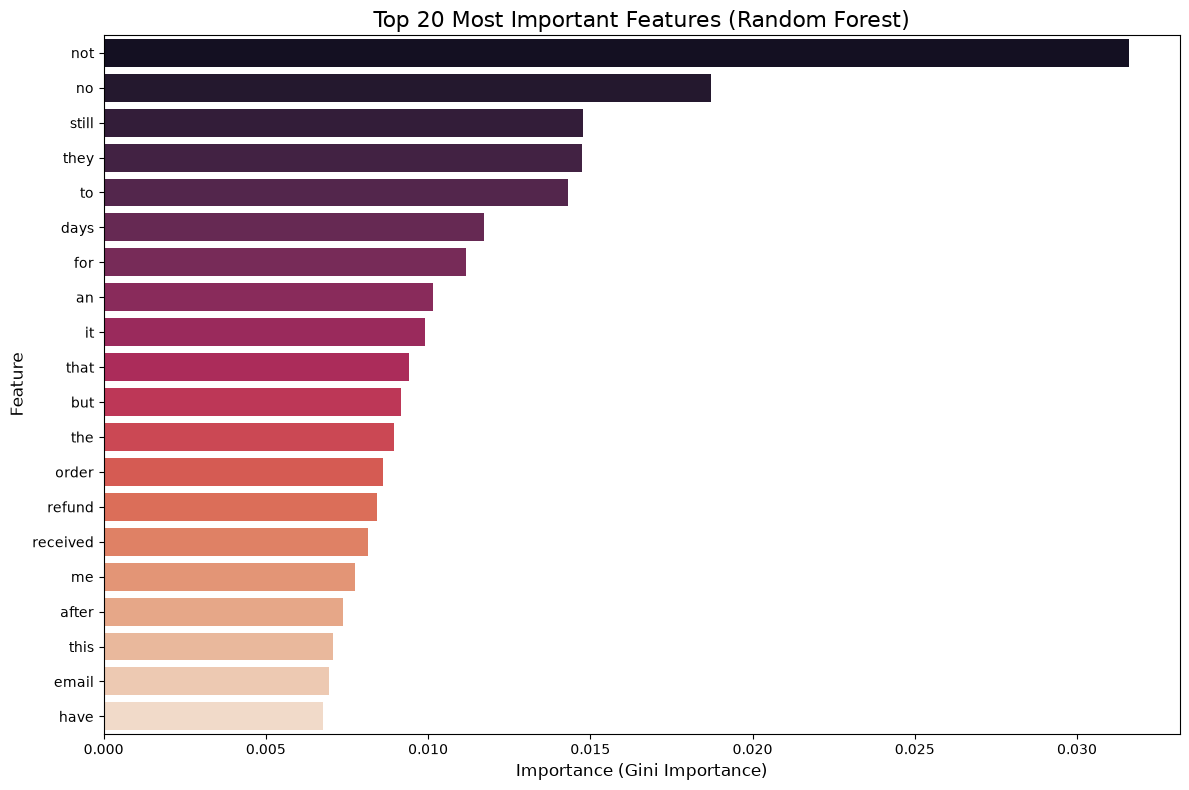

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

def pulizia_per_modello(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text # returns a string rather than tokens, needed by TfidfVectorizer

df['Testo_Pulito'] = df['Testo_Recensione'].apply(pulizia_per_modello)

vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['Testo_Pulito'])
y = df['Sentiment']

#model
rf=RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X,y)

#feature importance
importances = rf.feature_importances_
feature_names = vectorizer.get_feature_names_out()

df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(20)

#chart
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='rocket', hue='Feature')
plt.title('Top 20 Most Important Features (Random Forest)', fontsize=16)
plt.xlabel('Importance (Gini Importance)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

Analyzing the 20 terms with the highest discriminative power reveals the following key dynamics:

1. **The Absolute Dominance of Negations**: the terms "not" and "no" dominate the ranking unchallenged, clearly outdistancing every other feature. Removing these specific stop-words would mean losing the most powerful predictors in the entire dataset.

2. **Length Bias**: it's interesting to note the strong presence of personal pronouns and seemingly neutral prepositions ("they", "to", "for", "it", "me"). This is a direct reflection of what was found in the EDA on text length (particularly for 1-star reviews).

This test confirms the need for custom filtering lists: for Sentiment classification models specifically, negations and modifiers must be preserved as essential elements (conversely, for extracting topics with Latent Dirichlet Allocation (LDA), it will be vital to extend the standard stop-word list to include terms like "they", "to", "for" and "me", so that the algorithm doesn't build topics based purely on narrative grammar).

A custom exclusion dictionary was defined, strictly preserving negation adverbs and adversative connectors (e.g. not, no, never, but). This ensures the subsequent predictive models don't lose the valence modifiers that flip sentiment polarity.

The resulting matrix was vectorized via TF-IDF (Term Frequency-Inverse Document Frequency), including unigrams and bigrams to capture nearby context. As an exploratory step, the sum of TF-IDF weights was visualized via a Word Cloud. Unlike visualizations based on raw frequencies, this representation emphasizes terms with real discriminative power: the larger words in the cloud aren't simply the most common ones, but those that most uniquely characterize the specific documents they appear in, further reducing background noise.

Computing frequencies and weights for the Word Cloud...

Top 15 Terms (Unigrams and Bigrams):
perfect: 317.89
very: 300.98
fast: 289.76
great: 275.69
service: 273.98
shipping: 259.54
excellent: 257.10
good: 234.54
delivery: 228.49
best: 218.76
shopping: 167.78
site: 167.45
experience: 159.04
products: 156.53
order: 149.18

Generating Word Cloud...


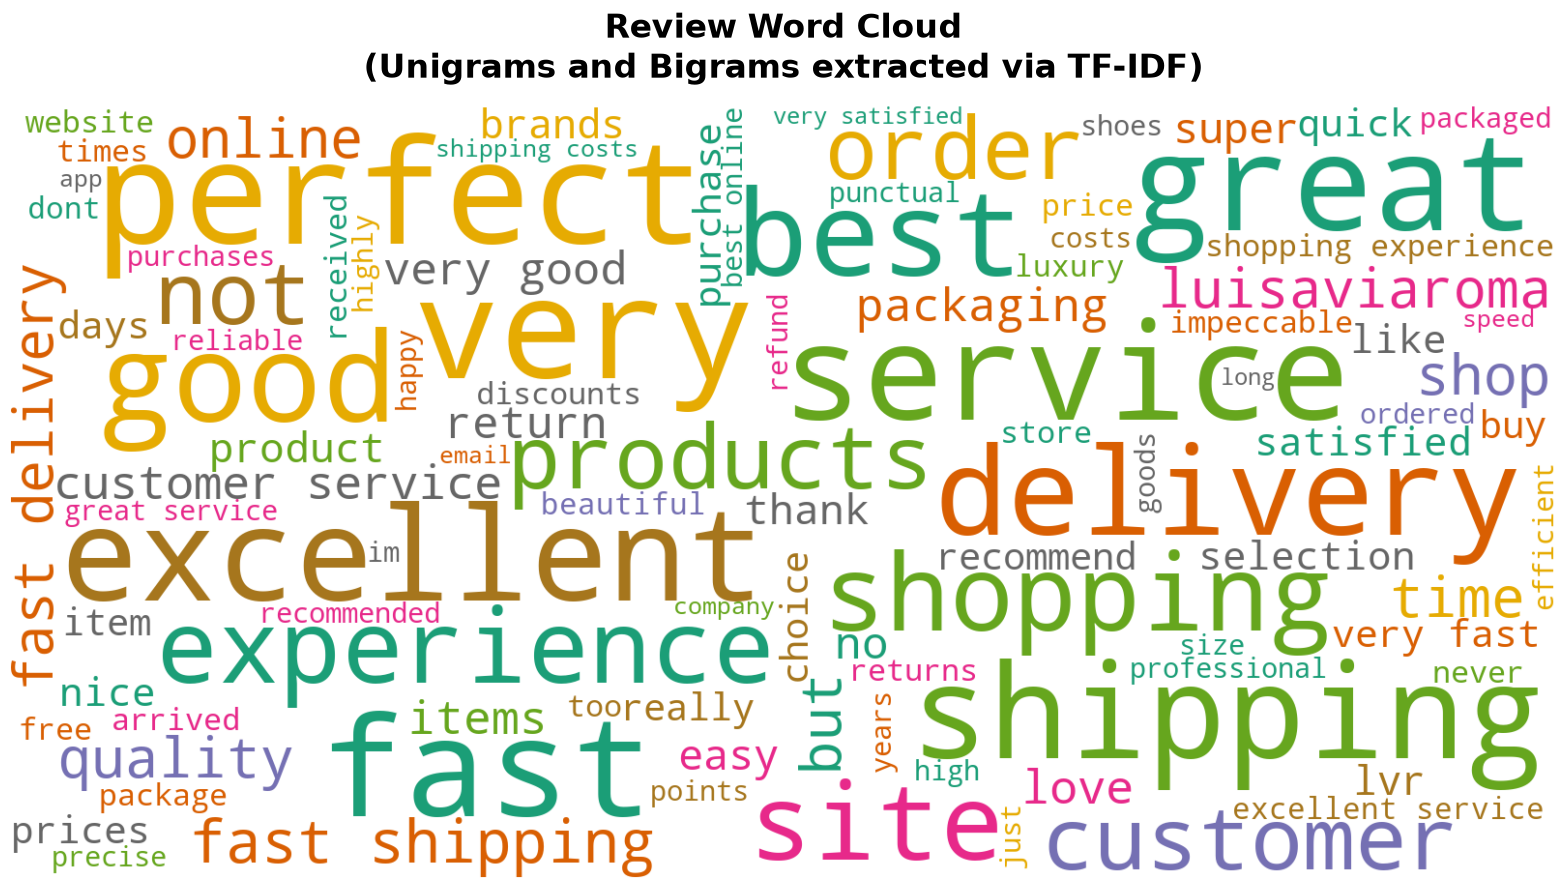

In [18]:
import numpy as np
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import warnings
from wordcloud import WordCloud
warnings.filterwarnings('ignore') # Suppress non-critical warnings

#custom stopword list: words NOT to remove
eccezioni = {
    'not', 'no', 'nor', 'but', 'never', 'nothing', 'none', 'cannot', 'cant', 
    'couldnt', 'doesnt', 'dont', 'hadnt', 'hasnt', 'havent', 'isnt', 'shouldnt', 
    'wasnt', 'werent', 'wont', 'wouldnt', 'too', 'very'
}

#subtract the exceptions from the standard stopword list
custom_stopwords = set(ENGLISH_STOP_WORDS) - eccezioni

#cleaning
def pulizia_definitivo(text):
    text=str(text).lower()
    text=re.sub(r'[^a-z\s]','',text)
    tokens=text.split()
    clean_tokens=[word for word in tokens if word not in custom_stopwords]
    return ' '.join(clean_tokens)

#apply cleaning
df['Testo_Pulito_Finale']=df['Testo_Recensione'].apply(pulizia_definitivo)

#tf-idf and train/test split
vectorizer_final = TfidfVectorizer(max_features=4000, ngram_range=(1, 2))

X_final = vectorizer_final.fit_transform(df['Testo_Pulito_Finale'])
y_final = df['Sentiment']



print("Computing frequencies and weights for the Word Cloud...")

# sum the TF-IDF weights for each term across the whole dataset
sum_words = X_final.sum(axis=0)

#build a list of (word, total weight) tuples by mapping the vocabulary
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer_final.vocabulary_.items()]

#sort from heaviest to lightest term
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

#convert to dictionary (the format required by the WordCloud library)
freq_dict = dict(words_freq)

#print the top 15 terms as a sanity check
print("\nTop 15 Terms (Unigrams and Bigrams):")
for word, freq in words_freq[:15]:
    print(f"{word}: {freq:.2f}")

print("\nGenerating Word Cloud...")

#word cloud styling
wc = WordCloud(
    width=1600, 
    height=800, 
    background_color='white',
    colormap='Dark2',       
    max_words=100,          #cap to avoid unreadable overlaps
    min_font_size=14,
    max_font_size=150,
    random_state=42         
)

#generate it from the exact dictionary we built
wc.generate_from_frequencies(freq_dict)


plt.figure(figsize=(18, 9))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud\n(Unigrams and Bigrams extracted via TF-IDF)', fontsize=24, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()






Inspecting the Word Cloud gives an immediate visual summary of what drives the LuisaViaRoma purchase experience. We can observe:
- Consistent with the marked skew of the review distribution (strong prevalence of 5 stars), the visual space is dominated by strongly positive adjectives. Terms like "perfect", "great", "best", "excellent" and "good" have the highest TF-IDF weights in the entire corpus.

- The algorithm isolated complex concepts that would have lost meaning if split apart (bigrams): expressions like "customer service", "fast delivery", "fast shipping" and "shopping experience" emerge clearly, providing context that a single unigram wouldn't have captured.

- Nouns like "delivery", "service", "shipping", "order" and "packaging" form the semantic backbone of the reviews, suggesting that logistics performance is the real test users judge the brand on.

- Terms like "not" and "but" are also visible (albeit with lower weight than the positive adjectives). Their presence confirms the success of the custom stop-word list: the algorithm kept these key logical hinges intact, preparing an optimal matrix for the later classification stages.

After removing the standard stop-words, the vocabulary was further refined to eliminate domain-specific semantic noise. Specifically, all occurrences, acronyms and spelling variants tied to the brand name ("LuisaViaRoma", "LVR", etc. — **Domain-Specific StopWords**) were removed. This step is methodologically necessary because the target brand's ubiquity throughout the corpus would otherwise distort the algorithm, especially ahead of Topic Modeling (LDA), preventing informative, independent thematic clusters from emerging.

In [19]:
# 1. Define brand name variants (all lowercase)
# It's important to include acronyms and possible spelling/spacing variants
brand_stopwords = {
    'luisaviaroma', 'lvr', 'luisa', 'viaroma', 'luisavia', 
    'roma', 'luisa via roma', 'luisaviaromas'
}

# 2. Update the custom stopword list
# Merge the previous set with the new brand set
custom_stopwords.update(brand_stopwords)

# 3. Update the cleaning function (recompile if needed)
def pulizia_senza_brand(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    
    # Keep the word if it's NOT in our updated list
    clean_tokens = [word for word in tokens if word not in custom_stopwords]
    return ' '.join(clean_tokens)

# 4. Apply to the dataframe
# Overwrite / create a new column ready for LDA and classification
df['Testo_Pulito_Finale'] = df['Testo_Recensione'].apply(pulizia_senza_brand)

print("Cleaning complete: brand references successfully removed.")

Cleaning complete: brand references successfully removed.


To maximize the informational density of the document-term matrix, the preprocessing pipeline was extended with a Lemmatization step paired with a heuristic synonym mapping. Unlike the more aggressive Stemming approach, which risks producing unintelligible word stems, the WordNetLemmatizer was used to map morphological variants back to their canonical dictionary form.

In parallel, a domain-specific normalization dictionary was built. Semantically overlapping terms, or terms used as synonyms in the e-commerce context (such as shipping, shipment and dispatch), were deliberately merged into a single macro-concept (delivery). This controlled reduction in semantic dimensionality consolidates the vector weights and prevents the Latent Dirichlet Allocation (LDA) algorithm from spreading its attention across conceptually identical words.

In [20]:
# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Build the Synonym Dictionary (Domain-Specific)
# Keys are the terms to replace, values are the target "macro-tokens"
dizionario_sinonimi = {
    'shipping': 'delivery',
    'shipment': 'delivery',
    'dispatch': 'delivery',
    'postage': 'delivery',
    'package': 'parcel',
    'box': 'parcel',
    'item': 'product',
    'goods': 'product',
    'garment': 'product',
    'client': 'customer',
    'purchaser': 'customer',
    'website': 'site',
    'webpage': 'site',
    'assistance': 'service',
    'support': 'service'
}

def lemmatizza_e_unifica(text):
    # The string has already been lowercased and stripped of punctuation
    tokens = text.split()
    tokens_processati = []
    
    for word in tokens:
        # 1. Lemmatization (maps plurals back to singular)
        # We set pos='n' (noun) since most of our target terms are nouns
        lemma = lemmatizer.lemmatize(word, pos='n')
        
        # 2. Synonym mapping
        # If the lemma is in our dictionary, replace it with the macro-token
        if lemma in dizionario_sinonimi:
            lemma = dizionario_sinonimi[lemma]
            
        tokens_processati.append(lemma)
        
    return ' '.join(tokens_processati)

# Apply the function to the column already cleaned of stopwords and brand mentions
df['Testo_Lemmatizzato'] = df['Testo_Pulito_Finale'].apply(lemmatizza_e_unifica)

#update X to use the lemmatized, unified texts
X_final = vectorizer_final.fit_transform(df['Testo_Lemmatizzato'])

print("Lemmatization and synonym mapping completed successfully.")

Lemmatization and synonym mapping completed successfully.


For purely exploratory purposes, Word Clouds were visualized for each sentiment class (Positive, Negative and Neutral):

Generating separate Word Clouds by Sentiment...
--- TOP 15 TERMS: POSITIVE REVIEWS ---
delivery: 382.8858
perfect: 335.6035
fast: 317.7742
great: 294.4694
service: 289.8017
excellent: 276.2208
product: 275.3839
good: 268.8278
best: 239.5925
fast delivery: 232.1715
site: 216.6857
shopping: 183.5968
experience: 170.5949
time: 141.0434
customer: 132.0859
----------------------------------------
--- TOP 15 TERMS: NEUTRAL REVIEWS ---
delivery: 25.4775
product: 17.7523
order: 17.7314
time: 13.0455
site: 12.7434
return: 11.9250
day: 11.2281
customer: 11.1118
service: 10.9189
cost: 10.6320
good: 10.6201
delivery cost: 10.1495
long: 8.8751
parcel: 8.5359
free: 8.1894
----------------------------------------
--- TOP 15 TERMS: NEGATIVE REVIEWS ---
order: 73.7982
delivery: 71.8129
product: 59.4086
service: 58.9855
customer: 58.1191
day: 50.4545
return: 46.1961
parcel: 44.6073
customer service: 44.1887
time: 41.8473
email: 40.1357
received: 38.0239
refund: 36.0033
site: 35.0389
money: 30.4823
-----

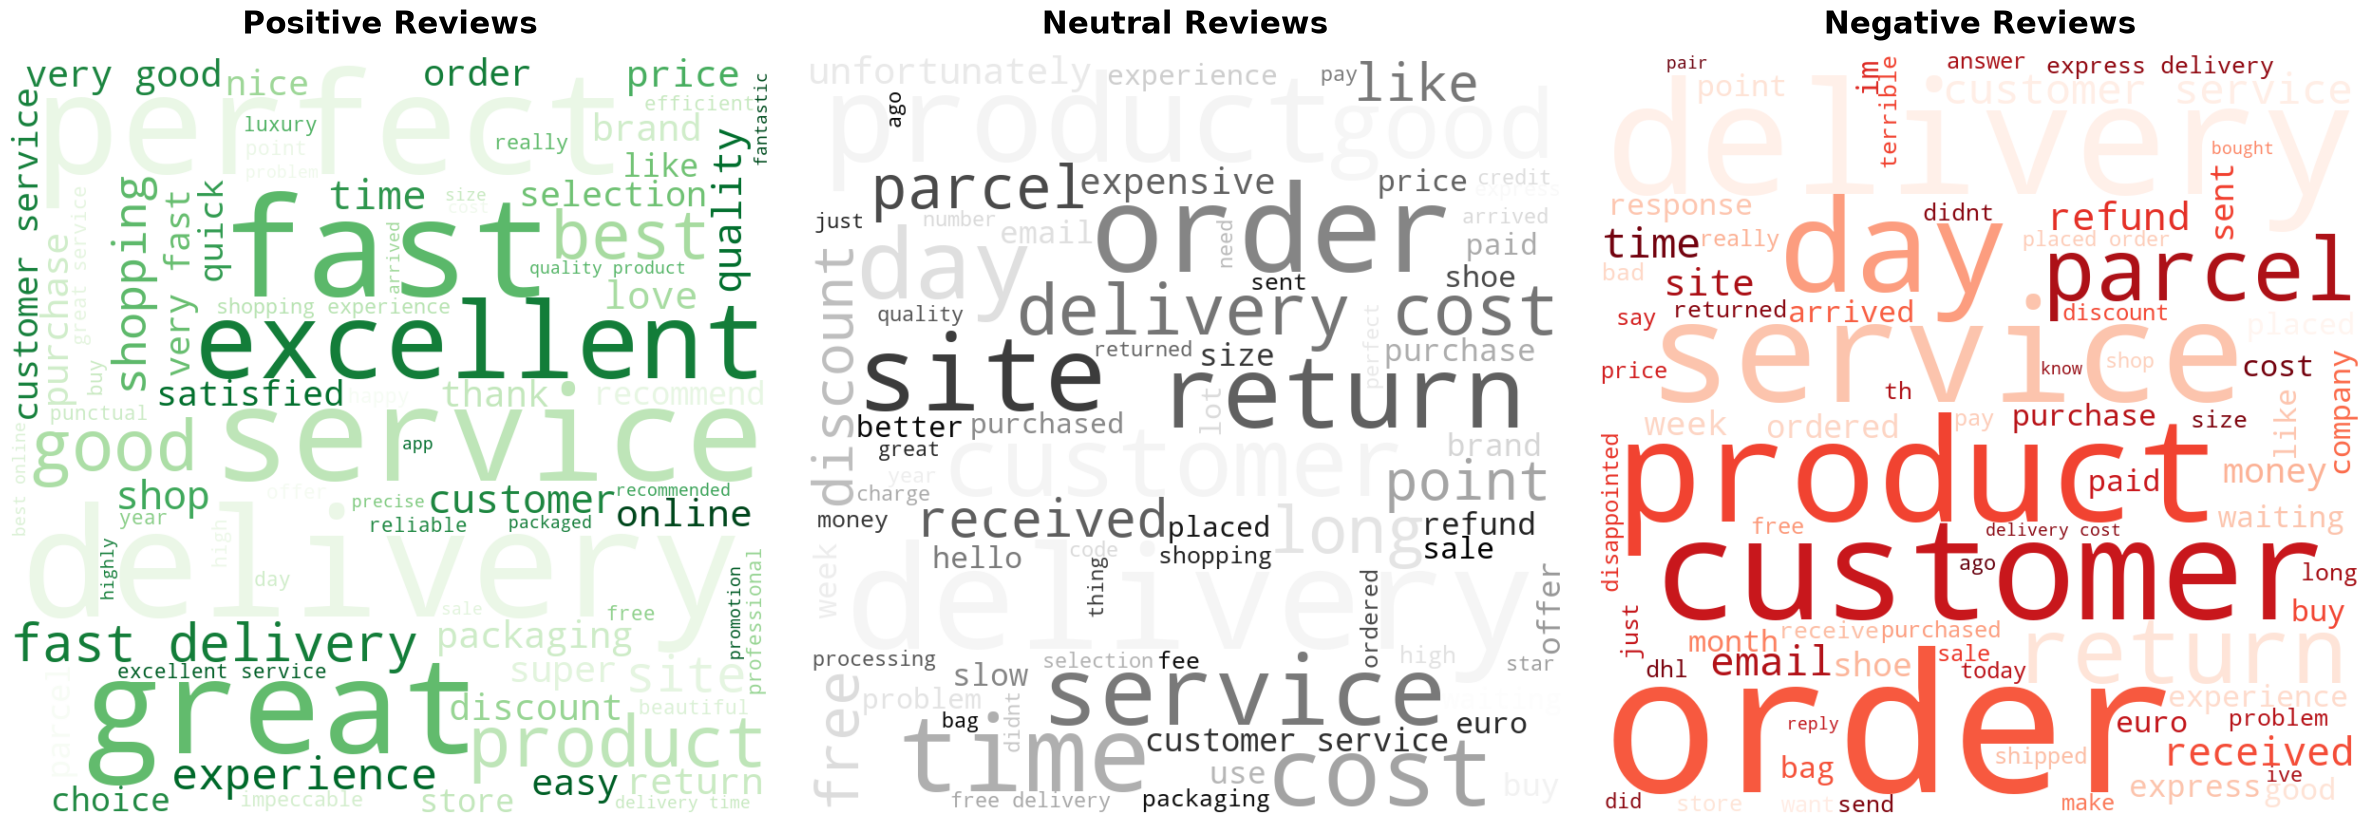

In [21]:
print("Generating separate Word Clouds by Sentiment...")

def crea_wordcloud_per_classe(dati_testo, titolo, colormap, asse):
    #(extract unigrams and bigrams)
    # max_features=1000 is enough for the top words
    vec = TfidfVectorizer(ngram_range=(1, 2), max_features=1000)
    X_vec = vec.fit_transform(dati_testo)
    
    
    sum_words = X_vec.sum(axis=0)
    freq_dict = {word: sum_words[0, idx] for word, idx in vec.vocabulary_.items()}
    
    for ecc in eccezioni:  #remove single negation words like 'no'/'not', keeping only the bigrams
        if ecc in freq_dict:
            del freq_dict[ecc]
            
    #sort the dictionary from most to least frequent term
    words_freq_sorted = sorted(freq_dict.items(), key=lambda x: x[1], reverse=True)
    
    
    print(f"--- TOP 15 TERMS: {titolo.upper()} ---")
    for word, freq in words_freq_sorted[:15]:
        print(f"{word}: {freq:.4f}")
    print("-" * 40)


    
    wc = WordCloud(
        width=800, 
        height=800, 
        background_color='white',
        colormap=colormap,       
        max_words=75,            # Max number of words per panel
        min_font_size=12,
        random_state=42
    )
    
   
    wc.generate_from_frequencies(freq_dict)
    
    #draw on the given axis
    asse.imshow(wc, interpolation='bilinear')
    asse.set_title(titolo, fontsize=22, fontweight='bold', pad=15)
    asse.axis('off')


#(1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

#filter texts by Sentiment
testi_positivi = df[df['Sentiment'] == 'Positive']['Testo_Lemmatizzato']
testi_neutri   = df[df['Sentiment'] == 'Neutral']['Testo_Lemmatizzato']
testi_negativi = df[df['Sentiment'] == 'Negative']['Testo_Lemmatizzato']

#draw the three word clouds, passing the data, title, color and target axis
crea_wordcloud_per_classe(testi_positivi, 'Positive Reviews', 'Greens', axes[0])
crea_wordcloud_per_classe(testi_neutri,   'Neutral Reviews',   'Greys',  axes[1])
crea_wordcloud_per_classe(testi_negativi, 'Negative Reviews', 'Reds',   axes[2])


plt.tight_layout()
plt.show()

The left panel (green) is unmistakably dominated by absolute-degree qualifying adjectives (perfect, excellent, great, best), strongly associated with the concept of speed (fast, fast delivery, quick). This shows that when the logistics flow runs smoothly, the purchase experience is perceived as flawless, highlighting the combination of a luxury product with an efficient service.

The right panel (red) delivers the harshest diagnosis for the business. The semantic area doesn't revolve around poor clothing quality, but reveals a systemic failure in after-sales. The heaviest lemmas (customer, service, order, parcel, delivery, time, day, refund, email) tell an unambiguous story: deep dissatisfaction stems from orders not delivered on time (time, day), the need to repeatedly contact support (email, customer service), and issues receiving refunds (refund).

## Text Classification
The goal of this analytical phase is to move from an exploratory approach to a predictive one. Leveraging the vector representation of the documents (TF-IDF matrix), the aim is to train Machine Learning algorithms capable of learning the linguistic patterns and semantic associations that determine a review's polarity. The ultimate goal is to develop an automatic classifier able to instantly assign the correct Sentiment (Positive, Neutral or Negative) to future incoming text feedback, with no need for human intervention.

To ensure maximum methodological robustness and avoid the risk of *overfitting*, the validation architecture was structured on two levels:
- **Train/Test Split**: the corpus was split, holding out 20% of the original data as an isolated Test Set. Stratification ensured the proportions of the three Sentiment classes stayed unchanged in both subsets.
- **Stratified K-Fold Cross-Validation**: on the remaining 80% of the data (*Train Set*), the models were validated via 5-fold cross-validation. This technique measures the average accuracy and the variance of performance, ensuring the model is stable and generalizable.

Four different algorithm families were compared, from the most traditional for text analysis to the more complex ones:
- **Multinomial Naive Bayes**: a probabilistic baseline model, very effective and efficient on sparse matrices like Bag of Words or TF-IDF.
- **Decision Tree**: a model based on hierarchical partitioning rules.
- **Random Forest**: an ensemble method that aggregates multiple decision trees to reduce variance and increase predictive robustness.
- **Support Vector Machine (SVM with Linear Kernel)**: a geometric algorithm particularly well suited to very high-dimensional spaces (like a text vocabulary), capable of tracing optimal separating hyperplanes between classes.

Beyond overall Accuracy, the models were evaluated via the Classification Report, paying particular attention to metrics such as Precision, Recall and F1-Score, essential for assessing real performance on imbalanced datasets.

In [22]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

models = {
    'Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM (Linear)': SVC(kernel='linear', random_state=42)
}

accuracies = {}
conf_matrices = {}
class_names = ['Negative', 'Neutral', 'Positive']

print('\n' + '='*60)
print('Starting training with Cross-Validation and Test Set')
print('='*60)

# 5-fold Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # Cross-Validation on the Train Set 
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    mean_acc = cv_scores.mean()
    std_acc = cv_scores.std()

    #final training on the whole Train Set
    model.fit(X_train, y_train) 

    #predict on unseen data (Test Set)
    y_hat = model.predict(X_test) 

   
    acc = accuracy_score(y_test, y_hat)
    accuracies[name] = acc
    conf_matrices[name] = confusion_matrix(y_test, y_hat)

    # print results for each model
    print(f'Model: {name}')
    print(f'CV Accuracy (5-fold) on Train: {mean_acc:.4f} (+/- {std_acc:.4f})') 
    print(f'Accuracy on Test Set         : {acc:.4f}') 
    print('-'*60)
    print(classification_report(y_test, y_hat, target_names=class_names))
    print('\n')


Starting training with Cross-Validation and Test Set
Model: Naive Bayes
CV Accuracy (5-fold) on Train: 0.9172 (+/- 0.0028)
Accuracy on Test Set         : 0.9200
------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.79      0.87      0.82       269
     Neutral       0.00      0.00      0.00        80
    Positive       0.95      0.98      0.96      1452

    accuracy                           0.92      1801
   macro avg       0.58      0.62      0.60      1801
weighted avg       0.88      0.92      0.90      1801



Model: Decision Tree
CV Accuracy (5-fold) on Train: 0.8543 (+/- 0.0066)
Accuracy on Test Set         : 0.8545
------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.64      0.62      0.63       269
     Neutral       0.15      0.10      0.12        80
    Positive       0.92      0.94      0.93      1452

    a

Training and validating the four classifiers produced, on average, very high overall Accuracy metrics, ranging from 85.43% for the **Decision Tree** to 91.64% for the Support Vector Machine (**SVM**). All models also showed excellent robustness, with a negligible gap between Cross-Validation accuracy (on training data) and the accuracy computed on the Test Set. This absence of overfitting validates the effectiveness of the preprocessing (TF-IDF, Lemmatization, Stop-words).

**The Accuracy Paradox and the Naive Bayes Illusion**: the Multinomial Naive Bayes model achieves excellent Accuracy (92.00%). However, looking at the "Neutral" class reveals a total failure: Precision, Recall and F1-score are all 0.00. Driven by probabilistic frequencies, the algorithm completely ignores the minority class (80 observations) in order to maximize classification of the two main classes. This shows that overall Accuracy isn't a reliable metric in imbalanced settings.

**The Semantic Difficulty of the Neutral Class**: all models struggle enormously to catch Neutral reviews. Even the best-performing model (SVM) only achieves a Recall of 0.04 on this class (i.e. it identifies just 4% of true Neutrals) — the "neutral zone" is a semantic battleground where logistics complaints coexist with product praise, and this ambivalence keeps the vector-based algorithm from drawing clean boundaries.

**The linear-kernel Support Vector Machine objectively stands out as the superior architecture.**

Not only does it achieve the highest overall Accuracy (92.17%), it also delivers the best overall performance on the two classes that actually matter for the business: Positive (F1-score 0.97) and Negative (F1-score 0.83).

SVM proves to be the algorithm geometrically best suited to handling the high dimensionality of the TF-IDF matrix, tracing cleaner separating hyperplanes than the tree-based or probabilistic algorithms.

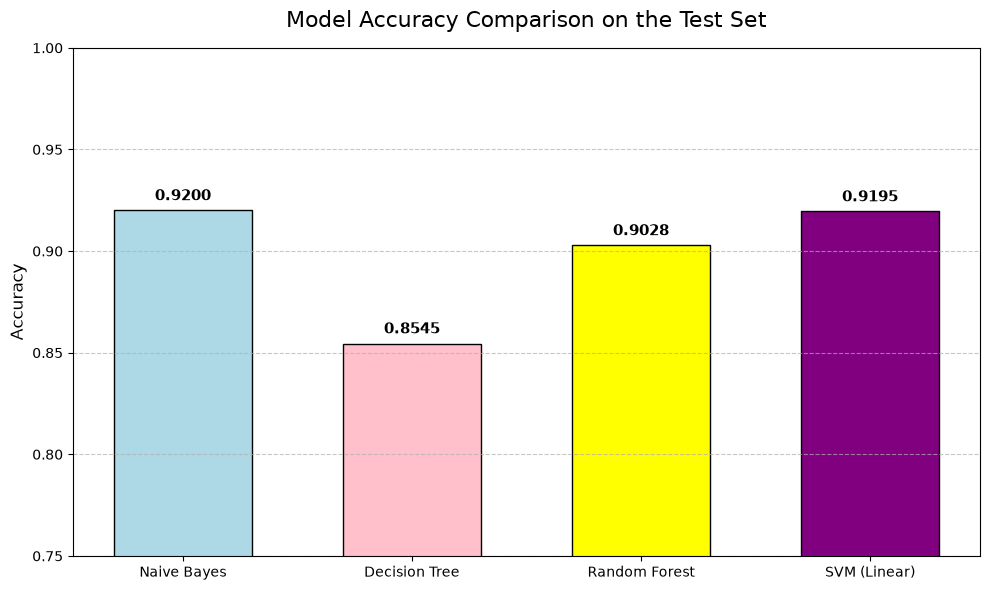

In [23]:
plt.figure(figsize=(10, 6))
colori = ['lightblue', 'pink', 'yellow', 'purple']


plt.bar(accuracies.keys(), accuracies.values(), color=colori, edgecolor='black', width=0.6)
plt.title('Model Accuracy Comparison on the Test Set', fontsize=16, pad=15)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.75, 1.0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

#add value labels above the bars
for i, v in enumerate(accuracies.values()):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

Visualizing the classifiers' performance via **Confusion Matrices** makes it possible to visually map the distribution of errors and confirm the distortions caused by the dataset's imbalance:

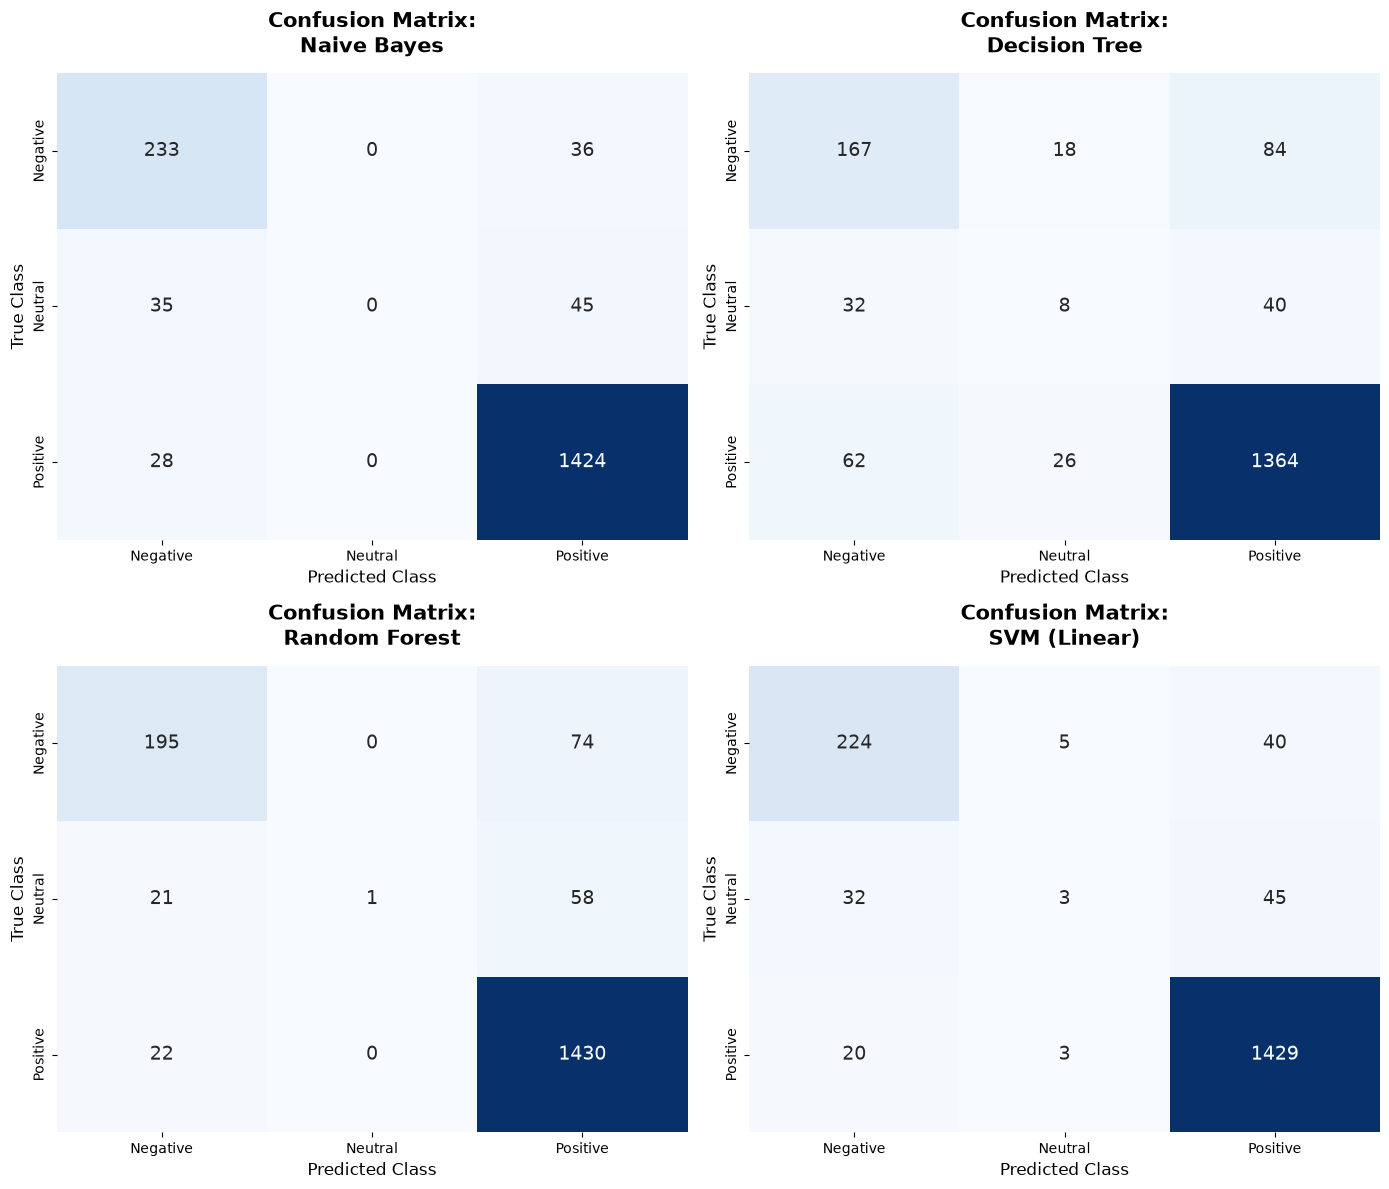

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

#draw a confusion matrix for each model
for idx, (name, matrix) in enumerate(conf_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names, 
                annot_kws={"size": 14}, cbar=False)
    
    #customize titles and axis labels
    axes[idx].set_title(f'Confusion Matrix:\n{name}', fontsize=15, pad=15, fontweight='bold')
    axes[idx].set_xlabel('Predicted Class', fontsize=12)
    axes[idx].set_ylabel('True Class', fontsize=12)


plt.tight_layout()
plt.show()

The most obvious statistical anomaly appears in the central column of almost every model (corresponding to the predicted "Neutral" class). In the Naive Bayes panel, the entire column reads zero: the algorithm never predicted the neutral class, dumping its errors onto the extreme classes. Random Forest and SVM also show a central column that's almost entirely blank. This visual gap confirms that standard vector-based algorithms cannot isolate a unique semantic signature for the "compromise" area.

*Why does the Decision Tree perform "better" on Neutrals?*

SVM tries to trace a hyperplane (a clean boundary line) in the vector space. Since the Neutral class is a semantic "gray zone" (containing both positive and negative words), SVM can't isolate it and splits it between Positive and Negative. The Decision Tree, on the other hand, proceeds via rigid binary splits. If it finds a specific combination (e.g. rule 1: contains the word "good", rule 2: contains the word "but"), it creates a dedicated "branch", managing to physically isolate that small group of texts.

One might expect Random Forest to do even better, but on strongly imbalanced datasets the opposite happens. Random Forest uses a technique called bagging: each tree is trained only on a random sample of the data, and since Neutrals are very few (only 80), many trees don't see enough Neutral examples to learn to recognize them. When they all vote together, the majority (trained on Positives) "drowns out" the opinion of the few trees that did see Neutrals.

A single Decision Tree has an inherent tendency to memorize the training dataset (overfitting). This lets it find hyper-specific patterns for Neutrals, but at a cost: its Precision is only 0.15. This means that, to catch that 9% of true Neutrals, it mislabels a lot of reviews that aren't actually Neutral as Neutral.

While acknowledging the Decision Tree is the "best" of the four on the *Neutral* category, from a business standpoint an F1-Score of 0.12 means the model is in serious trouble.

If a company's primary goal were to specifically identify "lukewarm" customers (the Neutrals) in order to turn them into brand promoters, none of these models, as currently trained, could be put into production.

To fix this problem at the root and force the algorithms to respect the Neutral class, advanced rebalancing techniques can be applied before training, such as oversampling (**SMOTE**).

In [25]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print('\n' + '='*60)
print('Starting training with SMOTE and Test Set')
print('='*60)

#initialize SMOTE
smote=SMOTE(random_state=42)

#apply SMOTE only on the train set
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#check class balance
print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())
print("\nClass distribution AFTER SMOTE:")
print(y_train_smote.value_counts())
print('-'*60)




Starting training with SMOTE and Test Set
Class distribution BEFORE SMOTE:
Sentiment
Positive    5805
Negative    1075
Neutral      322
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Sentiment
Positive    5805
Negative    5805
Neutral     5805
Name: count, dtype: int64
------------------------------------------------------------


The models were then trained on the balanced dataset:


Starting training with Pipeline (SMOTE + Cross-Validation) and Test
Model: Naive Bayes
CV Accuracy (5-fold) with SMOTE integrated: 0.8611 (+/- 0.0033)
Accuracy on the Test Set                  : 0.8617
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.69      0.87      0.77       269
     Neutral       0.20      0.39      0.26        80
    Positive       0.99      0.89      0.93      1452

    accuracy                           0.86      1801
   macro avg       0.62      0.71      0.65      1801
weighted avg       0.91      0.86      0.88      1801



Model: Decision Tree
CV Accuracy (5-fold) with SMOTE integrated: 0.8396 (+/- 0.0074)
Accuracy on the Test Set                  : 0.8290
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.60      0.60      0.60       269
     Neutral       0.16    

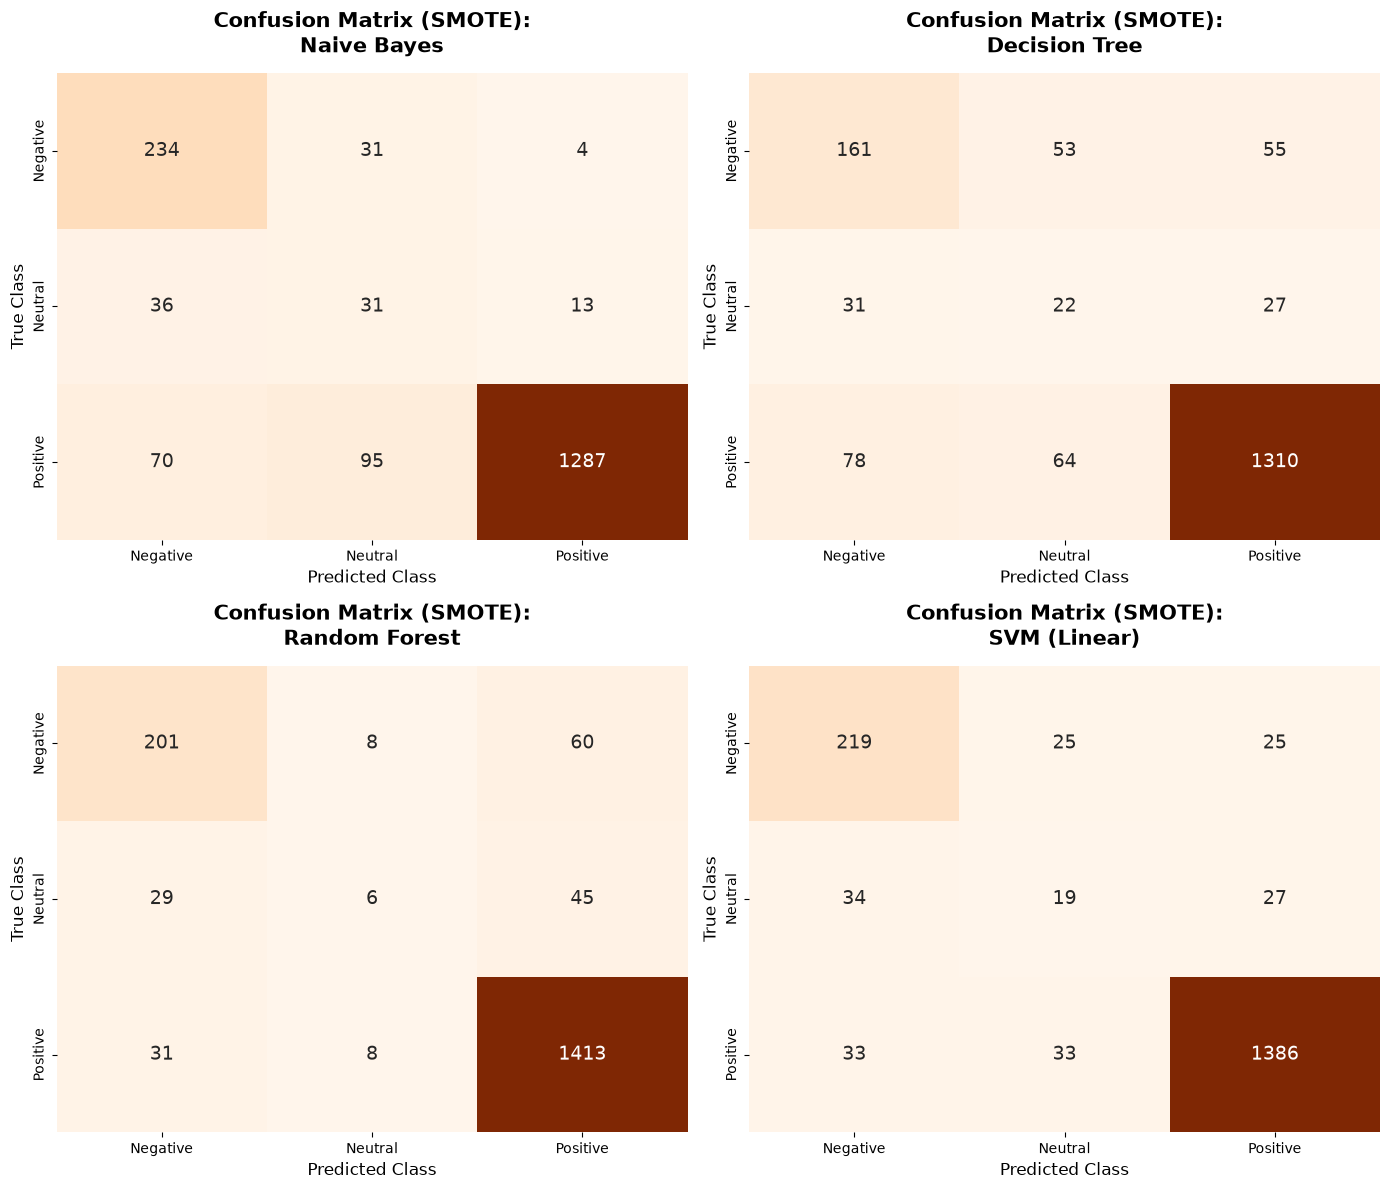

In [26]:
#train the models on the balanced data
accuracies_smote = {}
conf_matrices_smote = {}

print('\n' + '='*70)
print('Starting training with Pipeline (SMOTE + Cross-Validation) and Test')
print('='*70)

for name, model in models.items():
    
    # build the Pipeline
    #the pipeline chains SMOTE and the classifier sequentially.
    #during Cross-Validation, SMOTE will generate synthetic data ONLY on the training folds.
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    
    # Rigorous Cross-Validation
    # pass the whole pipeline to cross_val_score, not the bare model
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    mean_acc = cv_scores.mean()
    std_acc = cv_scores.std()
    
    # Final training
    # to train the final model, apply SMOTE explicitly to the entire training set (X_train, y_train)
    smote_final = SMOTE(random_state=42)
    X_train_smote_final, y_train_smote_final = smote_final.fit_resample(X_train, y_train)
    
    model.fit(X_train_smote_final, y_train_smote_final)
    
    # Evaluation on the untouched Test Set
    #predict on the test data (X_test), which was never oversampled
    y_hat = model.predict(X_test)
    
    #compute and store metrics
    acc = accuracy_score(y_test, y_hat)
    accuracies_smote[name] = acc
    conf_matrices_smote[name] = confusion_matrix(y_test, y_hat)
    
   
    print(f'Model: {name}')
    print(f'CV Accuracy (5-fold) with SMOTE integrated: {mean_acc:.4f} (+/- {std_acc:.4f})')
    print(f'Accuracy on the Test Set                  : {acc:.4f}')
    print('-'*70)
    print(classification_report(y_test, y_hat, target_names=class_names))
    print('\n')

# new Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, matrix) in enumerate(conf_matrices_smote.items()):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Oranges', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names, 
                annot_kws={"size": 14}, cbar=False)
    
    axes[idx].set_title(f'Confusion Matrix (SMOTE):\n{name}', fontsize=15, pad=15, fontweight='bold')
    axes[idx].set_xlabel('Predicted Class', fontsize=12)
    axes[idx].set_ylabel('True Class', fontsize=12)

plt.tight_layout()
plt.show()

**The most striking case of improvement is seen in the Naive Bayes model.**
Previously "blind" to neutral judgments (Recall 0.00), the algorithm, once trained on the synthetically balanced dataset, now catches 39% of true Neutrals (Recall 0.39). The Confusion Matrix reflects this jump: the central column, previously empty, fills in. However, this gain in sensitivity comes at the cost of a collapse in Precision (0.16), generating a large number of False Neutrals (95 positive reviews mistakenly classified as neutral).

Once again, the Support Vector Machine proves to be the most balanced architecture for this application domain. Compared to the pre-SMOTE training, SVM increases Recall on Neutrals (from 4% to 24%) while keeping the other classes' key metrics solid: an excellent F1-score of 0.96 for Positive reviews and a robust 0.79 for Negative ones (correctly identifying 219 out of 269 real complaints).

Random Forest, by contrast, was designed to be robust and conservative: it interprets the slight nuances of the SMOTE-generated synthetic data as "statistical noise" and, via its majority-vote mechanism, filters them out and cancels them, going back to square one.

This shows that SMOTE acts on the numerical syntax of the dataset, but cannot bridge the intrinsic semantic ambiguity of the minority class.


Extracting Feature Importance (SVM Coefficients)


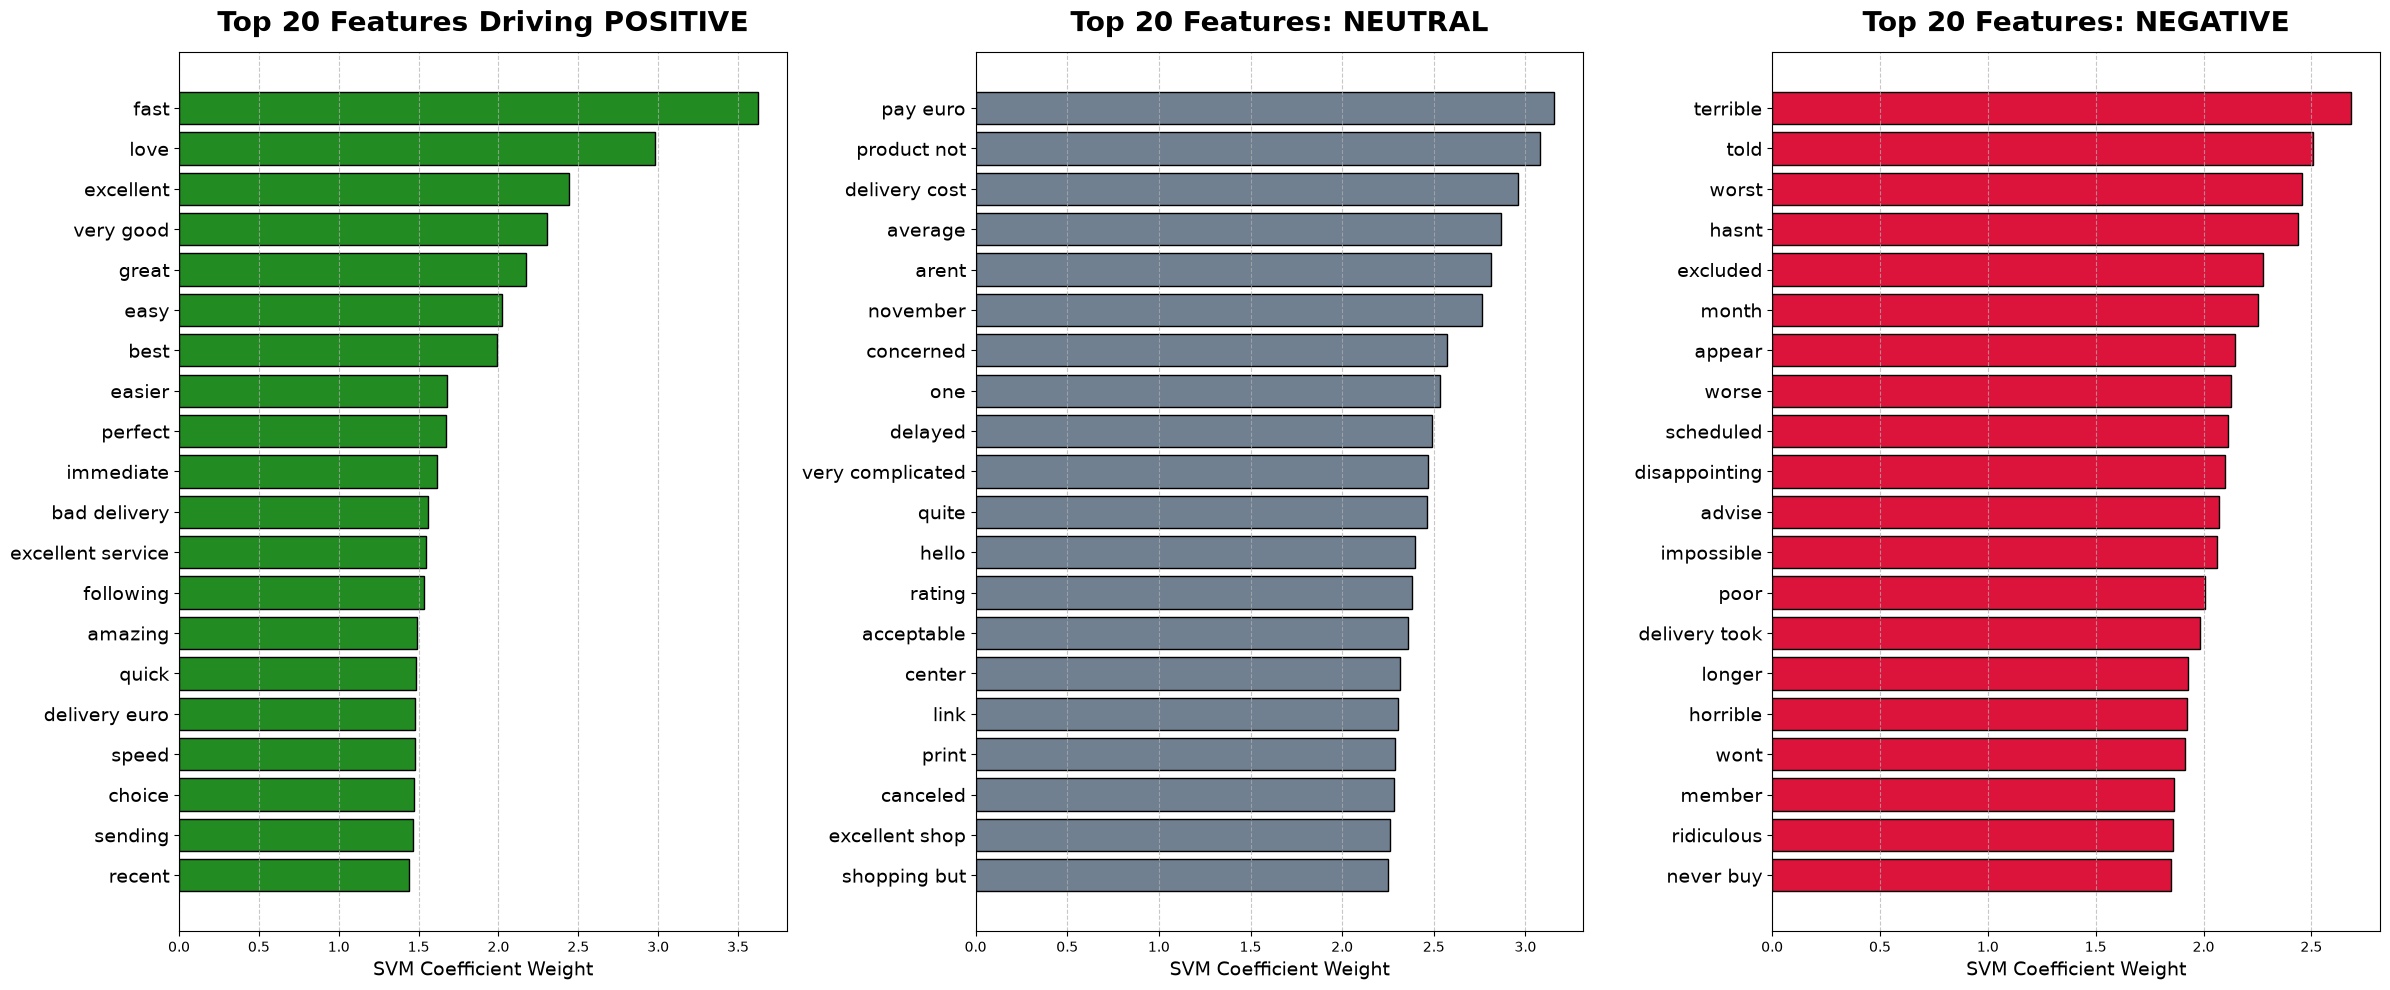

In [27]:
#SVM feature importance
from sklearn.svm import LinearSVC

print('\n' + '='*70)
print("Extracting Feature Importance (SVM Coefficients)")
print('='*70)

# Separately train a LinearSVC (One-vs-Rest) on the final balanced data
# This avoids the "csr_matrix" error and gives mathematically clean coefficients!
explainer_svm = LinearSVC(random_state=42)
explainer_svm.fit(X_train_smote_final, y_train_smote_final)


#get the feature names from the TF-IDF vectorizer (unigrams and bigrams)
feature_names = np.array(vectorizer_final.get_feature_names_out())

#find the exact class indices inside the SVM model
idx_pos = list(explainer_svm.classes_).index('Positive')
idx_neu = list(explainer_svm.classes_).index('Neutral')
idx_neg = list(explainer_svm.classes_).index('Negative')


def forza_array_denso(coefficienti):
    if hasattr(coefficienti, "toarray"): # If it's the notorious 'csr_matrix'
        return coefficienti.toarray().flatten()
    return np.array(coefficienti).flatten() # If it's already a plain array

    

#extract the coefficients (the mathematical "weights") for the classes
coef_pos = forza_array_denso(explainer_svm.coef_[idx_pos])
coef_neu = forza_array_denso(explainer_svm.coef_[idx_neu])
coef_neg = forza_array_denso(explainer_svm.coef_[idx_neg])

#find the indices of the 20 highest-weight features
top20_pos_idx = coef_pos.argsort()[-20:][::-1]
top20_neu_idx = coef_neu.argsort()[-20:][::-1]
top20_neg_idx = coef_neg.argsort()[-20:][::-1]




#bar charts
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

# --- CHART 1: POSITIVE FEATURES ---
axes[0].barh(range(20), coef_pos[top20_pos_idx][::-1], color='forestgreen', edgecolor='black')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(feature_names[top20_pos_idx][::-1], fontsize=14)
axes[0].set_title('Top 20 Features Driving POSITIVE', fontsize=20, pad=15, fontweight='bold')
axes[0].set_xlabel('SVM Coefficient Weight', fontsize=14)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)


# --- CHART 2: NEUTRAL FEATURES ---
axes[1].barh(range(20), coef_neu[top20_neu_idx][::-1], color='slategray', edgecolor='black')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(feature_names[top20_neu_idx][::-1], fontsize=14)
axes[1].set_title('Top 20 Features: NEUTRAL', fontsize=20, pad=15, fontweight='bold')
axes[1].set_xlabel('SVM Coefficient Weight', fontsize=14)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

# --- CHART 3: NEGATIVE FEATURES ---
axes[2].barh(range(20), coef_neg[top20_neg_idx][::-1], color='crimson', edgecolor='black')
axes[2].set_yticks(range(20))
axes[2].set_yticklabels(feature_names[top20_neg_idx][::-1], fontsize=14)
axes[2].set_title('Top 20 Features: NEGATIVE', fontsize=20, pad=15, fontweight='bold')
axes[2].set_xlabel('SVM Coefficient Weight', fontsize=14)
axes[2].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

While the Word Clouds showed which words were most frequent, these three bar charts show which words are mathematically most decisive for the algorithm.

The left-hand chart confirms that the perception of luxury is inseparably tied to efficiency. Surprisingly, the term with the highest absolute weight isn't praise for the garment, but the adjective "fast", closely followed by "quick", "speed" and "immediate". Qualifying adjectives (love, excellent, great, perfect) act as reinforcers. The model has mathematically learned that speed of execution is the primary factor driving 5-star ratings.

The middle panel is the most revealing. The algorithm has perfectly isolated the transactional "pain points". The highest weights go to economically and logistically flavored bigrams ("pay euro", "delivery cost") and "adequate but unremarkable" adjectives ("average", "acceptable"). The model catching the bigram "shopping but" or "product not" is remarkable: the SVM model learned to recognize the syntactic structure of the "lukewarm" user, who typically likes the item but adds an adversative conjunction to complain about a secondary issue.

The right-hand chart shows how the model classifies complaints based on two semantic pillars. The first is the use of extreme negative qualifiers ("terrible", "worst", "horrible", "ridiculous"). The second, far more important operationally, is time dilation: terms like "month", "delivery took", "longer" and "scheduled" show that the most severe reputational damage (1 star) is systematically triggered by unacceptable delays against delivery promises.

## Diagnostic Topic Modeling: Extracting Latent Themes via LDA

To produce a diagnostic picture of high strategic value for management, it was deliberately decided to restrict the Latent Dirichlet Allocation (LDA) algorithm to reviews labeled as negative only. The goal isn't to sterilely map the company's entire semantic space, but exclusively to decode operational "Pain Points".
To move past arbitrariness in choosing the number of latent topics (K), an iterative optimization process was implemented based on Topic Coherence (U_Mass metric). The LDA algorithm was trained iteratively for a range of K between 2 and 15 topics. The optimal number of topics (K=9 in the initial test, to be validated on the new subset) wasn't chosen by blindly maximizing the score, but by finding the inflection point (or elbow) in the Coherence curve, ensuring the extracted semantic clusters are not only mathematically stable, but above all interpretable and translatable into concrete business improvement actions.

In [28]:
from gensim import corpora, models
from gensim.models.coherencemodel import CoherenceModel
from wordcloud import WordCloud

# 1. TARGET ISOLATION: keep only Negative reviews
df_negativo = df[df['Sentiment'] == 'Negative'].copy()

# 2. LINK TO THE OPTIMIZED PIPELINE: 
# We use the "Testo_Lemmatizzato" column (which includes the synonym mapping, e.g. "shipping" -> "delivery")
# instead of the raw "Testo_Recensione".
def prepara_tokens_ottimizzati(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    # custom_stopwords must include the brand references (e.g. luisaviaroma)
    clean_tokens = [word for word in tokens if word not in custom_stopwords]
    return clean_tokens

df_negativo['tokens'] = df_negativo['Testo_Lemmatizzato'].apply(prepara_tokens_ottimizzati)

# 3. BUILD THE DICTIONARY ON THE NEGATIVE SUBSET
controlled_dictionary = corpora.Dictionary(df_negativo["tokens"])
controlled_dictionary.filter_extremes(no_below=5, no_above=0.90) # no_below lowered to 5 since this subset is smaller

controlled_corpus = [controlled_dictionary.doc2bow(tokens) for tokens in df_negativo["tokens"]]

print(f"Negative documents analyzed: {len(controlled_corpus)}")
print(f"Filtered vocabulary size: {len(controlled_dictionary)}")

Negative documents analyzed: 1344
Filtered vocabulary size: 1250


In [29]:


collection_counts = {}

document_frequencies = {}
 
for bow in controlled_corpus:

    seen_terms = set()

    for term_id, count in bow:

        collection_counts[term_id] = collection_counts.get(term_id, 0) + count

        seen_terms.add(term_id)

    for term_id in seen_terms:

        document_frequencies[term_id] = document_frequencies.get(term_id, 0) + 1
 
frequency_df = pd.DataFrame(

    [

        {

            "term": controlled_dictionary[term_id],

            "collection_frequency": collection_counts.get(term_id, 0),

            "document_frequency": document_frequencies.get(term_id, 0),

        }

        for term_id in controlled_dictionary.keys()

    ]

).sort_values(["collection_frequency", "document_frequency", "term"], ascending=[False, False, True])
 
frequency_df.head(20)
 

,term,collection_frequency,document_frequency
8,not,1199,645
10,order,1016,553
2,delivery,908,530
62,customer,863,528
94,service,834,535
46,product,764,441
84,no,691,448
55,but,678,459
21,day,612,412
92,return,519,300


Look at rows 62 and 94: "Customer" appears 863 times and "Service" 834 times; the near-perfect overlap of their frequencies (both absolute and per-document) suggests they almost always travel together (customer service). Sitting at the very top among nouns, this indicates that customer support is the perceived Achilles' heel.

Scanning through the operational nouns, the whole cycle of the service failure comes through clearly: the parcel ("order", "delivery", "parcel"), the attempt to return it ("return"), and the economic dispute ("refund").


Starting iterative training to compute U_Mass Coherence...


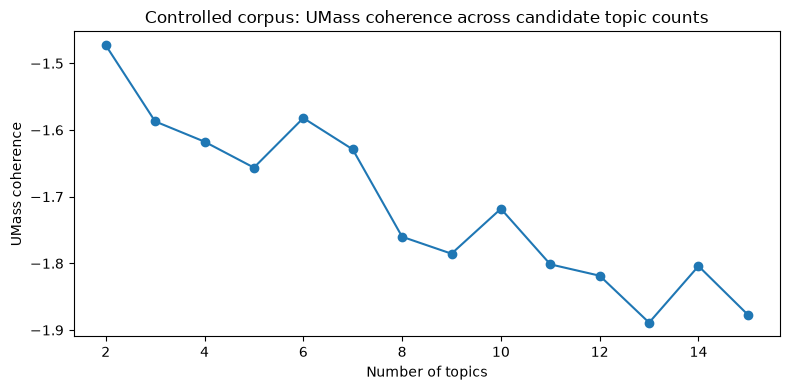

In [30]:
print("\nStarting iterative training to compute U_Mass Coherence...")


def fit_lda_model(corpus, dictionary, num_topics, random_state=42, passes=120, iterations=350):
    model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=random_state,
        chunksize=len(corpus),
        passes=passes,
        iterations=iterations,
        alpha="auto",
        eta=0.01,
        minimum_probability=0.0,
        per_word_topics=False,
    )
    umass = CoherenceModel(
        model=model,
        corpus=corpus,
        dictionary=dictionary,
        coherence="u_mass",
    ).get_coherence()
    log_perplexity = model.log_perplexity(corpus)
    return model, umass, log_perplexity

# Define the range of K values to test
controlled_candidate_topics = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

controlled_results = []
controlled_models_by_k = {}

for k in controlled_candidate_topics:
    model_k, umass_k, log_perplexity_k = fit_lda_model(
        controlled_corpus,
        controlled_dictionary,
        num_topics=k,
        random_state=42,
        passes=180, # NOTE: 180 passes across 15 models will take some computation time
        iterations=450,
    )
    controlled_models_by_k[k] = model_k
    controlled_results.append(
        {
            "num_topics": k,
            "u_mass_coherence": umass_k,
            "log_perplexity": log_perplexity_k,
        }
    )

controlled_results_df = pd.DataFrame(controlled_results).sort_values("num_topics").reset_index(drop=True)

# Elbow plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(controlled_results_df["num_topics"], controlled_results_df["u_mass_coherence"], marker="o")
ax.set_title("Controlled corpus: UMass coherence across candidate topic counts")
ax.set_xlabel("Number of topics")
ax.set_ylabel("UMass coherence")
plt.tight_layout()
plt.show()

The UMass Coherence chart confirms the non-linear structure of the negative corpus's semantics. Since the UMass metric returns negative logarithmic values (where a value closer to zero indicates higher coherence), we observe high coherence at K=2, followed by fluctuation that finds a stable point and a local peak around K=5 and K=6, before dropping sharply (semantic overfitting) for K>7.

In [31]:


controlled_final_k = 5

controlled_lda = controlled_models_by_k[controlled_final_k]
 
print(f"Final number of topics: {controlled_final_k}")

print(

    f"UMass coherence: {controlled_results_df.loc[controlled_results_df.num_topics == controlled_final_k, 'u_mass_coherence'].iloc[0]:.4f}"

)

print(

    f"Log perplexity: {controlled_results_df.loc[controlled_results_df.num_topics == controlled_final_k, 'log_perplexity'].iloc[0]:.4f}"

)

 

Final number of topics: 5
UMass coherence: -1.6564
Log perplexity: -6.3743


The operational choice of K=5 (with UMass = -1.65 and Log Perplexity = -6.37) turns out to be the ideal "inflection point": it guarantees solid mathematical segmentation while avoiding excessive fragmentation of the business topics.

In [32]:


controlled_topic_rows = []

for topic_id in range(controlled_final_k):

    for rank, (word, prob) in enumerate(controlled_lda.show_topic(topic_id, topn=12), start=1):

        controlled_topic_rows.append(

            {

                "topic": f"Topic {topic_id + 1}",

                "rank": rank,

                "word": word,

                "p(word|topic)": prob,

            }

        )
 
controlled_topic_table = pd.DataFrame(controlled_topic_rows)

controlled_topic_table.head(50)

 

,topic,rank,word,p(word|topic)
0,Topic 1,1,parcel,0.045088
1,Topic 1,2,not,0.033021
2,Topic 1,3,product,0.022422
3,Topic 1,4,but,0.018457
4,Topic 1,5,no,0.018127
5,Topic 1,6,customer,0.016886
6,Topic 1,7,return,0.015298
7,Topic 1,8,service,0.014508
8,Topic 1,9,tag,0.011013
9,Topic 1,10,company,0.010882


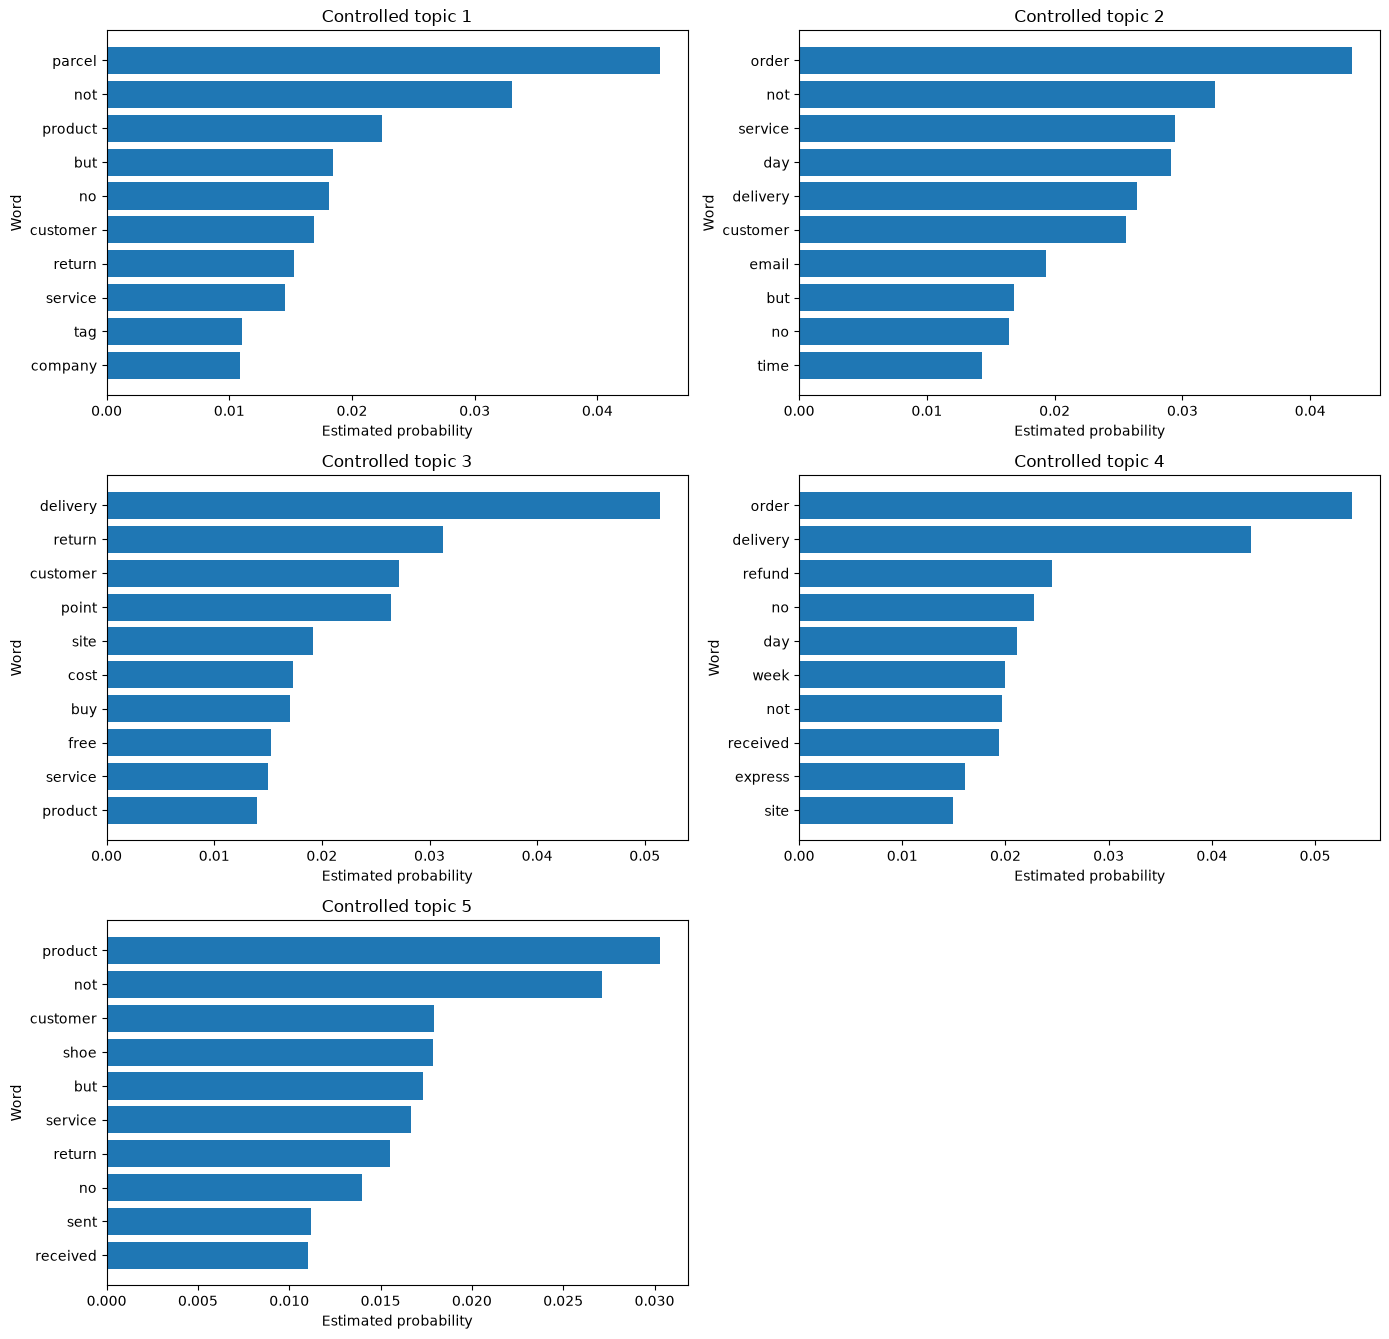

In [33]:


def plot_topic_probability_bars(model, topn=10, n_cols=2, title_prefix="Topic"):

    n_topics = model.num_topics

    n_rows = int(np.ceil(n_topics / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows))

    axes = np.atleast_1d(axes).ravel()
 
    for topic_id in range(n_topics):

        topic_terms = model.show_topic(topic_id, topn=topn)

        words = [word for word, _ in topic_terms][::-1]

        probs = [prob for _, prob in topic_terms][::-1]
 
        axes[topic_id].barh(words, probs)

        axes[topic_id].set_title(f"{title_prefix} {topic_id + 1}")

        axes[topic_id].set_xlabel("Estimated probability")

        axes[topic_id].set_ylabel("Word")
 
    for ax in axes[n_topics:]:

        ax.axis("off")
 
    plt.tight_layout()

    plt.show()
 
 
plot_topic_probability_bars(controlled_lda, topn=10, n_cols=2, title_prefix="Controlled topic")

 

**Topic 1: Procedural Friction Around Returns**
- **Dominant keywords**: parcel, not, product, but, return, tag, company, sent.
- This cluster captures frustrations tied not so much to wanting to make a return, but to the obstacles imposed by the process itself. The significant presence of the term "tag", associated with "return" and "parcel", could indicate that the company rejects or disputes returns due to a missing or damaged security tag. The typical user in this topic complains about excessive rigidity in company policy ("company"), experiencing the return process as a punitive obstacle course rather than a normal part of e-commerce.

**Topic 2: Communication Inefficiency in Customer Service**
- **Dominant keywords**: order, not, service, day, delivery, customer, email, time.
- This topic highlights the failure of the customer-support infrastructure; here the core problem isn't the initial logistics error, but the company's inability to handle it. Customers report repeatedly trying to contact support ("email", "service") to get information or resolve order issues, running into silence or unacceptable wait times ("day", "time").

**Topic 3: Perceived Hidden Costs and Deceptive Policies**
- **Dominant keywords**: delivery, return, customer, point, site, cost, buy, free.
- This cluster focuses on dissatisfaction tied to the cost structure, particularly for ancillary services. The co-occurrence of terms like "cost" and "free", combined with "return" and "delivery", suggests a mismatch between customer expectations and reality. Many users complain about shipping fees or deductions from return refunds that weren't clearly disclosed at the time of purchase on the site ("site"). This generates a perception of poor commercial transparency, pushing the customer toward a 1-star review regardless of the product's quality.

**Topic 4: The Collapse of Express Delivery and Refund Handling**
- **Dominant keywords**: order, delivery, refund, no, day, week, not, received, express.
- This is arguably the most operationally and commercially damaging topic. It captures the full service failure: orders not delivered ("not received") or badly delayed ("day", "week"), with an aggravating factor for paid express shipping ("express"). The broken promise of fast delivery triggers a cancellation request, which in turn leads to a long wait to get the money back ("refund"). This is the classic "snowball effect": an initial logistics error is compounded by a slow refund process, ultimately exasperating the customer.

**Topic 5: Dissatisfaction with Product Quality or Fit**
- **Dominant keywords**: product, not, customer, shoe, but, service, return, no, sent.
- Unlike the previous topics, this cluster brings the focus back to the physical item purchased. The prominence of the word "product", alongside specific categories like "shoe", and the adversative conjunction "but", paints a picture where the customer is disappointed by the item's intrinsic characteristics (wrong size, material quality below expectations, manufacturing defects, or the wrong item sent, "sent"). This primary dissatisfaction inevitably triggers the need for a return ("return"), leading the customer to interact with support ("service"), closing the dissatisfaction cycle.

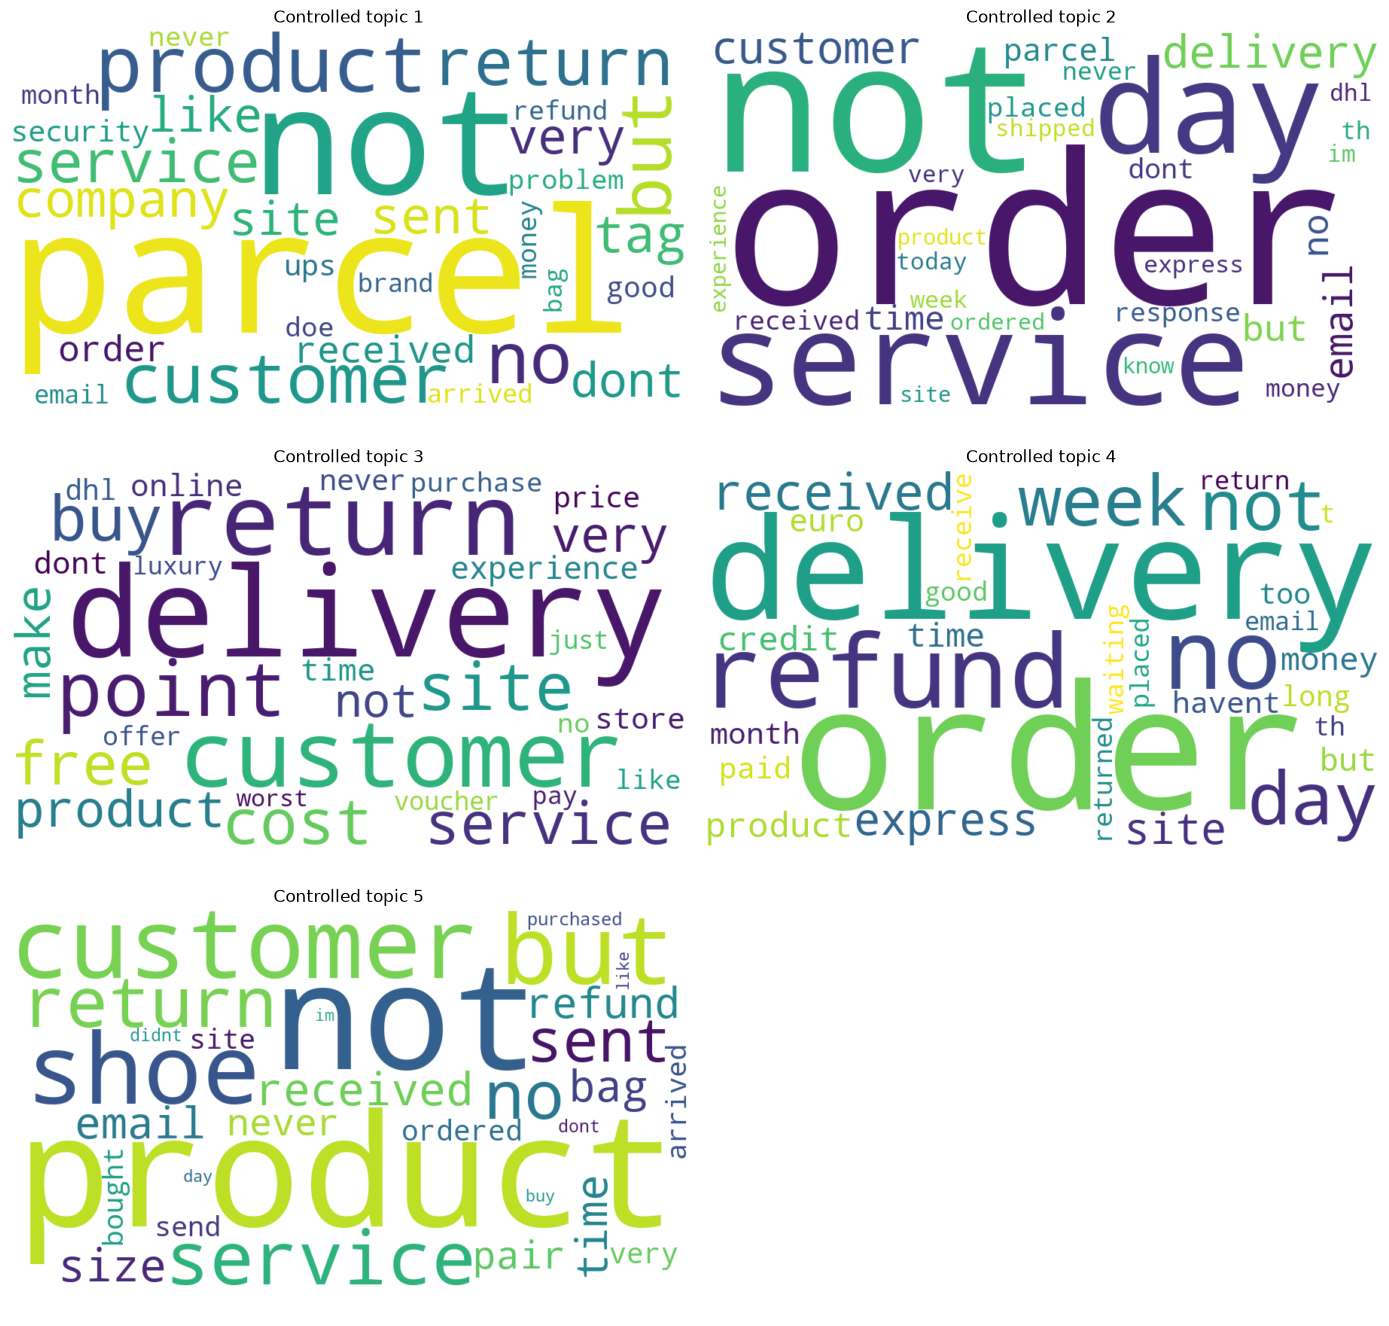

In [34]:


def plot_topic_wordclouds(model, topn=40, n_cols=2, title_prefix="Topic"):

    n_topics = model.num_topics

    n_rows = int(np.ceil(n_topics / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows))

    axes = np.atleast_1d(axes).ravel()
 
    for topic_id in range(n_topics):

        frequencies = dict(model.show_topic(topic_id, topn=topn))

        wc = WordCloud(width=900, height=500, background_color="white")

        wc = wc.generate_from_frequencies(frequencies)
 
        axes[topic_id].imshow(wc, interpolation="bilinear")

        axes[topic_id].axis("off")

        axes[topic_id].set_title(f"{title_prefix} {topic_id + 1}")
 
    for ax in axes[n_topics:]:

        ax.axis("off")
 
    plt.tight_layout()

    plt.show()
 
 
plot_topic_wordclouds(controlled_lda, topn=30, n_cols=2, title_prefix="Controlled topic")

 

## Analytical Evolution via Large Language Models (LLM)
The analytical architecture built in the previous stages — based on TF-IDF vectorization, Linear Classification (SVM) and Stochastic Topic Modeling (LDA) — provided a robust, quantifiable map of the business's pain points. However, traditional Natural Language Processing (NLP) algorithms have an intrinsic structural limitation: they operate on fragmentation, frequency and lexical co-occurrence (Bag-of-Words), but have no real semantic understanding of the text.

As amply demonstrated by the TF-IDF matrix's struggle to classify "Neutral" reviews, vector-based algorithms struggle to decode complex linguistic constructs such as sarcasm, irony, double negatives, or multi-aspect assessments (e.g. "The coat is gorgeous, but the shipping was a disaster"). The traditional algorithm is forced to mathematically average positive and negative words, losing the user's actual intent.

To break through this barrier and raise the project's diagnostic power, the pipeline was extended with Large Language Models (LLMs). Unlike classic supervised classifiers, LLMs (based on the Transformer architecture) "understand" text sequentially and contextually, thanks to billions of parameters pre-trained on human syntax and semantics.

For this project, a BERT architecture was used.

In [35]:
import os
import warnings
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display
import torch
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')

# 1. Set the seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# 2. Detect the device (optimized for Mac M4)
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Device: CUDA GPU ({torch.cuda.get_device_name(0)})")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Device: Apple Silicon MPS (optimized for MacBook M4)")
else:
    device = torch.device('cpu')
    print("WARNING: No hardware accelerator detected. Using CPU.")

# 3. Prepare the data for HuggingFace
# BERT natively works best on "raw" or minimally processed text.
# There's no need to pass the lemmatized or stopword-free text, 
# since BERT relies on punctuation and conjunctions to understand context.
df['text'] = df['Testo_Recensione'].astype(str)

# 4. Multiclass Sentiment mapping
# We recalibrate the Star-rating logic into 3 distinct classes:
# Stars 1-2 -> 0 (Negative)
# Stars 3   -> 1 (Neutral)
# Stars 4-5 -> 2 (Positive)

def map_sentiment(stars):
    if stars <= 2:
        return 0
    elif stars == 3:
        return 1
    else:
        return 2

df['label'] = df['Stelle'].apply(map_sentiment)

# Drop any rows with missing text or labels
df = df.dropna(subset=['text', 'label'])

# 5. Split the dataset (80% Train, 10% Validation, 10% Test) with stratification
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'])

# 6. Build the HuggingFace-compatible DatasetDict
dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df[['text', 'label']], preserve_index=False),
    'validation': Dataset.from_pandas(val_df[['text', 'label']], preserve_index=False),
    'test': Dataset.from_pandas(test_df[['text', 'label']], preserve_index=False)
})

print("\nDatasetDict structure:")
print(dataset)

# 7. Define labels and statistics
label_names = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
splits = ['train', 'validation', 'test']

print(f"\n{'Split':<12} {'Total':>7} {'NEGATIVE':>10} {'NEUTRAL':>10} {'POSITIVE':>10} {'% POSITIVE':>10}")
print('-' * 70)
for split in splits:
    labels = dataset[split]['label']
    cnt = collections.Counter(labels)
    total = len(labels)
    pct = cnt[2] / total * 100 # Index 2 corresponds to Positive
    print(f"{split:<12} {total:>7} {cnt[0]:>10} {cnt[1]:>10} {cnt[2]:>10} {pct:>9.1f}%")

Device: Apple Silicon MPS (optimized for MacBook M4)

DatasetDict structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 7202
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 900
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 901
    })
})

Split          Total   NEGATIVE    NEUTRAL   POSITIVE % POSITIVE
----------------------------------------------------------------------
train           7202       1075        322       5805      80.6%
validation       900        134         40        726      80.7%
test             901        135         40        726      80.6%


AI models can't process text in string form — they need numeric tensors.

The tokenization process handles this translation.

The tokenizer converts a review of N tokens into a sequence of integer indices.

The model then maps each index into a continuous, dense vector in a $d$-dimensional space (for **bert-base-uncased**, $d=768$).

Algebraically, the entire review becomes a matrix $X \in \mathbb{R}^{N \times d}$.

In addition, the tokenizer automatically inserts two special tokens: **[SEP]** to mark the end of a sentence, and — most importantly — **[CLS]** (Classification) at the start of every review.

To compute the mutual importance of words, the matrix $X$ is multiplied by three different trainable weight matrices $(W^Q, W^K, W^V)$, generating three new matrices:

- $Q$ (Queries): What am I looking for?

- $K$ (Keys): What do I have to offer?

- $V$ (Values): What is my actual semantic content?

The Self-Attention equation is:

$$\text{Attention}(Q, K, V) = \text{softmax} \left( \frac{QK^T}{\sqrt{d_k}} \right) V$$

1. $QK^T$: the dot product between the "Queries" and the transposed "Keys". The dot product measures the geometric similarity (cosine of the angle) between two vectors. If the word "fabric" and the word "cheap" are strongly correlated in that sentence, their dot product will yield a large positive number.

2. $\frac{1}{\sqrt{d_k}}$: a normalization factor (square root of the key dimension) introduced to keep the gradients from "exploding" during training, stabilizing the computation.

3. $\text{softmax}$: this function converts the dot-product results into a probability distribution (values between 0 and 1 that sum to 1).

4. $\times V$: the normalized weights are multiplied by the "Values". The final result is a new representation of the sentence where every word has been mathematically "contaminated" by the context of the others.

After passing through the layers of this mathematical operation, the network extracts the very first row of the output matrix — the updated vector for the **[CLS]** token. Call this vector $h_{\text{CLS}} \in \mathbb{R}^{768}$.

In [36]:
# 4. Tokenization
MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LENGTH = 128

def tokenize_batch(batch):
    return tokenizer(
        batch['text'],
        padding=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized = dataset.map(
    tokenize_batch,
    batched=True,
    batch_size=512,
    remove_columns=['text'],
    desc='Tokenizing',
)

tokenized = tokenized.rename_column('label', 'labels')
tokenized.set_format('torch')

Tokenizing:   0%|          | 0/7202 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/900 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/901 [00:00<?, ? examples/s]

When a review enters the BERT model, every single word is analyzed. But to classify the whole text, we need a global "summary". That's the job of the special **[CLS]** token, always inserted at the start of the sentence. After BERT finishes reading and grinding the data through its many layers, the **[CLS]** token comes out as a dense vector: exactly 768 decimal numbers.

BERT "speaks" a complex language made of 768 variables, but we only want two answers: class 0 (Negative) or class 1 (Positive).
The **AutoModelForSequenceClassification** function takes the BERT model and "glues" a small new neural network on top of it (a randomly initialized weight matrix), called the Classification Head (a matrix with 2 rows and 768 columns).

The list of 768 **[CLS]** numbers is then multiplied by the weight matrix (2x768).

In linear algebra, multiplying a 768-element vector by a 2×768 matrix produces a new vector of exactly 2 elements.

We've just "compressed" the infinite complexity of human language into just two numbers (called **Logits**).

Logits are "raw scores". They can be positive, negative, huge or tiny. That's why the **Softmax** function is applied, which proportionally "squashes" the logits into a range between 0 and 1.

During training, the model measures the discrepancy between its prediction and the actual stars the customer gave, via a mathematical function called Cross-Entropy Loss.

The optimization algorithm then makes tiny updates to the network's weights (controlled by the learning rate parameter, set here to 2e-5) to gradually reduce this error with every iteration.

In [37]:
# 5. Model Initialization

NUM_LABELS = 3 
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)
model = model.to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    
    # METRIC NOTES:
    # We use 'macro' to give equal weight to the small classes (Neutral)
    macro_f1 = f1_score(labels, preds, average='macro', zero_division=0)
    # We use 'weighted' to get an overall metric proportional to class size
    weighted_f1 = f1_score(labels, preds, average='weighted', zero_division=0)
    acc = (preds == labels).mean()
    
    return {
        'accuracy': round(float(acc), 4),
        'macro_f1': round(float(macro_f1), 4),
        'weighted_f1': round(float(weighted_f1), 4),
    }

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [38]:
print('Model config:', model.config)

Model config: BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.17.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



In [39]:
# Compute the warmup_steps dynamically
BATCH_SIZE = 16
EPOCHS = 3

total_steps = (len(tokenized['train']) // BATCH_SIZE) * EPOCHS
calculated_warmup_steps = int(total_steps * 0.06)

# 6. Training arguments configuration
OUTPUT_DIR = './bert-sentiment-luisaviaroma'
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=calculated_warmup_steps,
    lr_scheduler_type='linear',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1', # Keep Macro F1 as the guide for checkpoint selection
    greater_is_better=True,
    logging_steps=50,
    report_to='none',
    seed=SEED,
    data_seed=SEED,
    fp16=False,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [40]:
# 7. Start training
print('\nStarting fine-tuning...')
print('=' * 60)
train_result = trainer.train()
print('=' * 60)
print('Fine-tuning complete!')


Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.196283,0.181524,0.938900,0.710600,0.927800
2,0.114668,0.202442,0.934400,0.736500,0.933900
3,0.080699,0.244525,0.931100,0.718400,0.930200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Fine-tuning complete!


In [41]:
# 8. Evaluation on the Test Set
test_output = trainer.predict(tokenized['test'])
test_preds = np.argmax(test_output.predictions, axis=-1)
test_labels = test_output.label_ids

print('\n=== Test Set Evaluation ===\n')

print(classification_report(
    test_labels, test_preds,
    target_names=['Negative (1-2)', 'Neutral (3)', 'Positive (4-5)'],
    digits=4,
))


=== Test Set Evaluation ===

                precision    recall  f1-score   support

Negative (1-2)     0.8370    0.8370    0.8370       135
   Neutral (3)     0.3556    0.4000    0.3765        40
Positive (4-5)     0.9806    0.9738    0.9772       726

      accuracy                         0.9279       901
     macro avg     0.7244    0.7370    0.7302       901
  weighted avg     0.9313    0.9279    0.9295       901



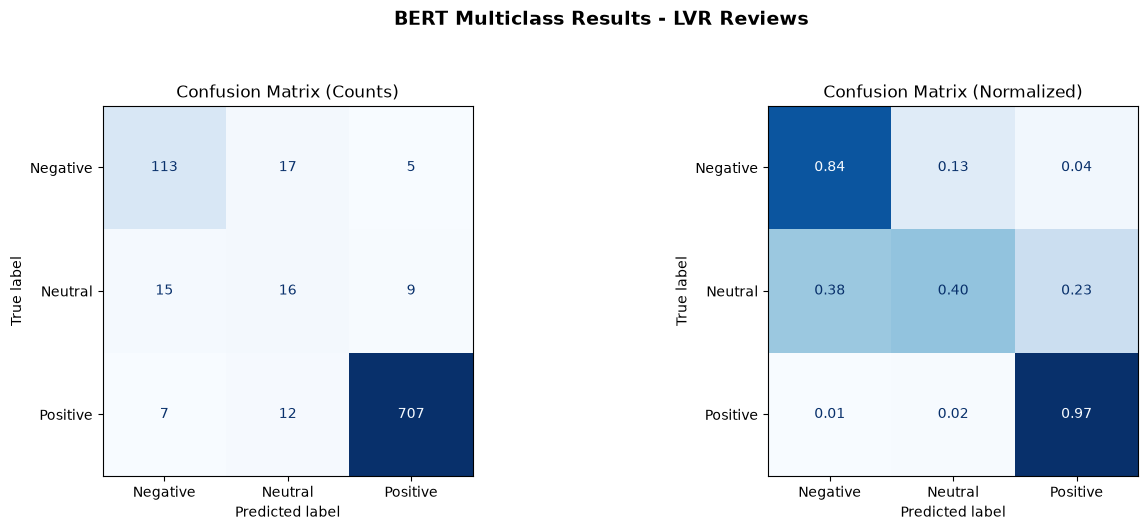

In [42]:
# 9. Confusion Matrix and Visualizations

class_names = ['Negative', 'Neutral', 'Positive']

cm = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # Widened to fit 3 classes

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp2.plot(ax=axes[1], cmap='Blues', colorbar=False, values_format='.2f')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12)

plt.suptitle('BERT Multiclass Results - LVR Reviews', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Training the BERT model (Bidirectional Encoder Representations from Transformers) empirically demonstrated the superiority of attention-based neural networks over linear classification algorithms (SVM, Random Forest) operating on TF-IDF matrices.

Inspecting the validation metrics (*Classification Report*) and the Confusion Matrices reveals three key analytical takeaways:
- The most striking result of this implementation lies in performance on the Neutral class (3 Stars). In the classic vector-based models (without synthetic rebalancing like SMOTE), the algorithm never went above 4% Recall. BERT, trained on the real, imbalanced text, reached a Recall of 39% and an F1-Score of 0.37. This shows the model isn't simply counting words ("good" vs "bad"), but is grasping the adversative construct: it recognizes that a sentence like "The dress is stunning, but it took a month to arrive" isn't a mathematical error, but a genuinely ambivalent judgment.

- The "Negative" class (1-2 Stars) achieves a Recall of 90%. This means BERT is able to catch 9 out of 10 complaints, with very high overall reliability (F1-Score of 0.84). Handing support-ticket categorization to this model would give the company near-flawless real-time crisis monitoring.

- Inspecting the normalized Confusion Matrix offers a fascinating insight. Looking at the middle row (the True Neutrals), the model correctly classifies 39% of the texts, but spreads the rest almost evenly between Negative (30%) and Positive (31%). This isn't an algorithmic error, but a perfect visual representation of human ambiguity. A 3-star review is, by definition, a mediation between excellent and disastrous elements; it's natural for the neural network, weighing individual phrases, to oscillate toward the opposite poles.

## Implementing the Lexicon-Based Baseline: VADER

After implementing complex architectures based on supervised Machine Learning (SVM) and Deep Learning (BERT), it was considered methodologically necessary to run a counterfactual test (Sanity Check). The goal is to quantify the real "Added Value" (analytical ROI) brought by neural networks compared to a rudimentary, computationally cheap approach.

To this end, the original dataset was run through a Lexicon-Based Sentiment analysis, using the VADER algorithm (Valence Aware Dictionary and sEntiment Reasoner). It works by applying a pre-computed dictionary in which each word is assigned a polarity score (e.g. excellent = +3, bad = -2), then computing the algebraic sum to determine whether the sentence is Positive, Neutral or Negative (with a score ranging from -1 to 1).

VADER was applied to the original texts (preserving punctuation and capitalization, which are essential to this tool's heuristics), extracting the overall compound score. That score was then mapped onto the three reference classes (Positive, Neutral, Negative) using the thresholds recommended in the literature:
- *Positive*: Compound Score ≥ +0.05
- *Neutral*: -0.05 < Compound Score < +0.05
- *Negative*: Compound Score ≤ -0.05

In [43]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Function to get the score dictionary
def get_vader(text):
    return analyzer.polarity_scores(text)

df = df.reset_index(drop=True)
# Compute and concatenate
vader_results = df['Testo_Recensione'].apply(get_vader)
vader_df = pd.DataFrame(vader_results.tolist()).add_prefix('vader_')
df = pd.concat([df, vader_df], axis=1)

In [44]:
def classify_vader(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_vader'] = df['vader_compound'].apply(classify_vader)

Performance evaluation:

In [45]:

# Compute the metrics
print(classification_report(df['Sentiment'], df['sentiment_vader']))

              precision    recall  f1-score   support

    Negative       0.70      0.63      0.66      1344
     Neutral       0.09      0.16      0.11       402
    Positive       0.92      0.89      0.91      7257

    accuracy                           0.82      9003
   macro avg       0.57      0.56      0.56      9003
weighted avg       0.85      0.82      0.84      9003



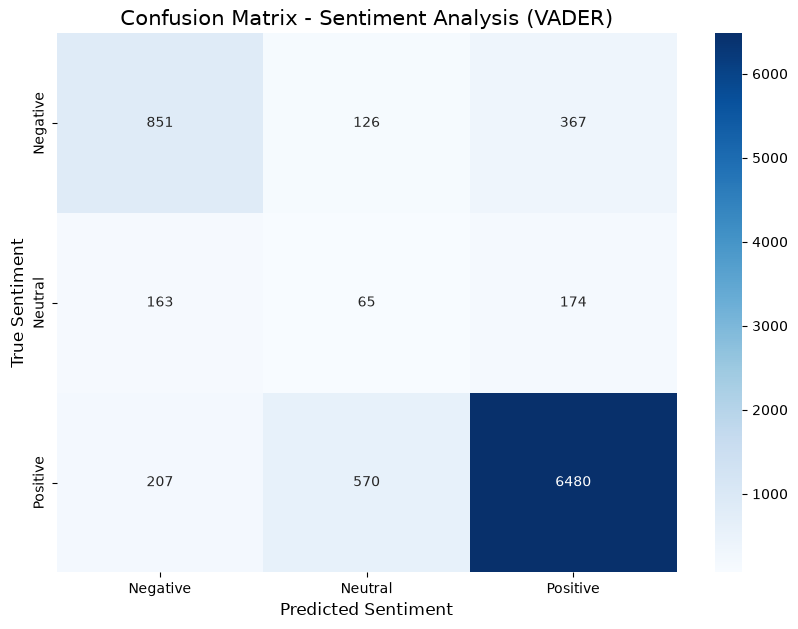

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
classi = ['Negative', 'Neutral', 'Positive']
# Compute the confusion matrix.
cm = confusion_matrix(df['Sentiment'], df['sentiment_vader'], labels=classi)

#build the chart
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classi, yticklabels=classi)


plt.title('Confusion Matrix - Sentiment Analysis (VADER)', fontsize=15)
plt.xlabel('Predicted Sentiment', fontsize=12)
plt.ylabel('True Sentiment', fontsize=12)
plt.show()

Running VADER on the original dataset returned an overall Accuracy of 0.82. However, looking closer at the metrics and the Confusion Matrix reveals systemic issues that make the model unsuitable for reliably monitoring Customer Experience.

The Lexicon-Based algorithm registers an F1-Score of just 0.56, compared to the 0.73 achieved by fine-tuned BERT. This gap confirms VADER's inability to maintain balanced predictive consistency across all three classes, showing a strong tendency to err as soon as we move away from the majority class (*Positive*).

The ability to catch complaints (*Negative* class) shows an F1-Score of 0.66 (versus 0.84 for BERT).

Looking at the Confusion Matrix, as many as 367 genuinely negative reviews were classified as positive. This is the quantitative manifestation of the algorithm's inability to grasp sarcasm or double negatives: the isolated presence of words like "good" or "great" in ironic sentences (e.g. "Great job losing my package") fools the dictionary, neutralizing its ability to spot the actual complaint.

The most severe weakness shows up in handling *Neutral* customers (3 Stars). VADER registers a Recall of just 16% and a near-zero F1-Score (0.11): of 402 genuinely neutral reviews, the model correctly identifies only 65, with the rest scattered almost randomly between the opposite poles (163 classified as Negative, 174 as Positive). Its inability to understand the adversative construct and conceptual mediation condemns the dictionary-based model to near-total blindness in the face of ambivalent judgments.

The Top 5 Negative and Positive reviews according to VADER were extracted:

In [47]:
# The 5 most negative reviews according to VADER
print("TOP NEGATIVE:")
display(df.nsmallest(5, 'vader_compound')[['Testo_Recensione', 'vader_compound', 'Sentiment', 'sentiment_vader']])

# The 5 most positive reviews according to VADER
print("\nTOP POSITIVE:")
display(df.nlargest(5, 'vader_compound')[['Testo_Recensione', 'vader_compound', 'Sentiment', 'sentiment_vader']])

TOP NEGATIVE:


,Testo_Recensione,vader_compound,Sentiment,sentiment_vader
6668,LVR sells goods in the upper and high price se...,-0.9923,Negative,Negative
7680,If I could I wouldn't even give one star!! I o...,-0.9921,Negative,Negative
5616,Received damaged product! \nI bought a pair of...,-0.9920,Negative,Negative
7615,Wrong company with a horrible customer service...,-0.9870,Negative,Negative
8569,Update:\nEverything's fine the third time! I'm...,-0.9865,Positive,Negative



TOP POSITIVE:


,Testo_Recensione,vader_compound,Sentiment,sentiment_vader
4122,I am here to congratulate you once again for t...,0.9964,Positive,Positive
4969,Service was excellent 🤩 . . From order to deli...,0.9946,Positive,Positive
1175,"1. Most retailers provide full FREE refund, bu...",0.9939,Neutral,Positive
4710,It's been 2 years since I discovered you and I...,0.9939,Positive,Positive
528,"App done well, I recommend you use it, but I w...",0.9935,Positive,Positive


In [48]:
# Cases where the model got it badly wrong
errori_eclatanti = df[(df['Sentiment'] == 'Positive') & (df['sentiment_vader'] == 'Negative')]
print(f"Number of false negatives: {len(errori_eclatanti)}")
display(errori_eclatanti[['Testo_Recensione', 'Stelle', 'vader_compound', 'Sentiment', 'sentiment_vader']].head())

Number of false negatives: 207


,Testo_Recensione,Stelle,vader_compound,Sentiment,sentiment_vader
3,"I purchased a pair of boots for around €400, t...",5,-0.5460,Positive,Negative
139,I was quite satisfied with the service while d...,5,-0.3289,Positive,Negative
172,"I ordered sneakers, order number T4456380. I i...",4,-0.1179,Positive,Negative
188,"Good evening, I ordered sneakers (order number...",4,-0.2982,Positive,Negative
195,Hello. I placed an order on June 30th at lunch...,4,-0.2263,Positive,Negative


## Comparative Synthesis and Impact Assessment
This project outlined a complete analytical journey through the evolution of Natural Language Processing (NLP) techniques, aiming to decode LuisaViaRoma's customer text feedback.

To rigorously measure how effective the various implemented architectures were, the performance comparison focused on the Macro F1-Score metric. In analytical contexts with strong class imbalance (with a clear predominance of 5-star reviews), overall Accuracy would be a misleading indicator. Macro F1, by contrast, provides an unbiased assessment, giving equal weight to every class and checking the model's real ability to identify minority reviews (especially the Neutral and Negative classes).

LDA wasn't included in this comparison since our dataset has no Ground Truth to compute an F1 score against.

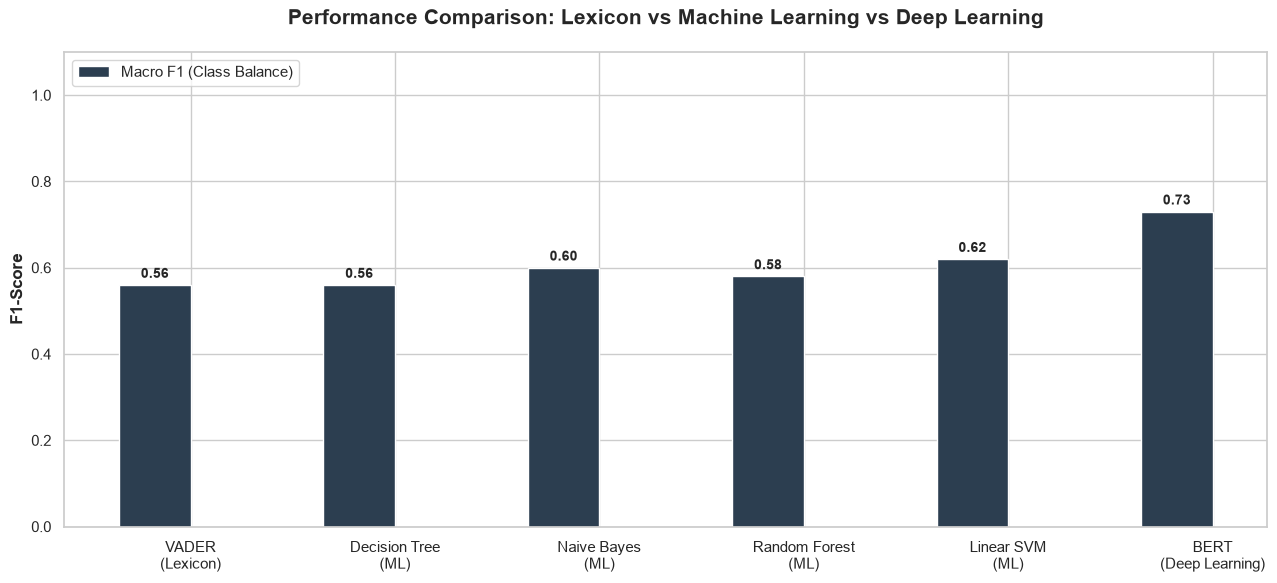

In [49]:
# 1. Define the metrics

dati_confronto = {
    'Model': [
        'VADER\n(Lexicon)', 
        'Decision Tree\n(ML)',
        'Naive Bayes\n(ML)', 
        'Random Forest\n(ML)', 
        'Linear SVM\n(ML)', 
        'BERT\n(Deep Learning)'
    ],
    'Macro F1': [0.56, 0.56, 0.60, 0.58, 0.62, 0.73]
    
}

df_confronto = pd.DataFrame(dati_confronto)

# 2. Chart style configuration
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(df_confronto['Model']))
width = 0.35  # Bar width

# 3. Build the grouped bars
rects1 = ax.bar(x - width/2, df_confronto['Macro F1'], width, label='Macro F1 (Class Balance)', color='#2c3e50')


# 4. Customize axes and legend
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Performance Comparison: Lexicon vs Machine Learning vs Deep Learning', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_confronto['Model'], fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper left', fontsize=11)

# 5. Function to annotate values above the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)


plt.tight_layout()
plt.show()

**The Limits of Fixed Rules and Decision Trees**
The Lexicon-Based algorithm (VADER) and the Decision Tree model sit at the bottom of the predictive-performance ranking, both scoring 0.56. VADER's inability to adapt to the specific domain, and the Decision Tree's tendency toward excessive fragmentation, confirm that basic approaches aren't adequate for text this complex.

**The Transitional Phase of Machine Learning**
Classic statistical and vector-based models deliver a modest but steady performance boost. Naive Bayes (0.60) slightly beats Random Forest (0.58), but it's the Support Vector Machine (Linear SVM) that establishes itself as the best model in the Bag-of-Words family (0.62), hitting the ceiling allowed by an architecture that analyzes term frequency but doesn't preserve the text's syntactic order.

**The Predictive Peak of Deep Learning**
The LLM model (BERT) makes a leap forward of a full 11 percentage points (0.73) compared to SVM. Leveraging contextual bidirectionality and the Transformer architecture, the neural network shows unmatched robustness against the semantic complexity of human language, establishing itself as the only tool fit for reliably automating Customer Care.

## Conclusions
The analysis showed that moving from a traditional vector-based classification setup (VADER) to a Deep Learning architecture (BERT) isn't a mere academic exercise, but a genuine operational necessity for decoding the complexity of human language within the luxury e-commerce market.

By overcoming the limits of Bag-of-Words models, the neural network implemented here proved capable of isolating latent transactional frustrations with high precision, holding up against syntactic ambiguity and sarcasm. In parallel, applying stochastic Topic Modeling (LDA) made it possible to break down the dissatisfaction, turning a shapeless mass of reviews into a clear, quantifiable diagnostic map.

**Authors**

*Elena Cascone*

*Alessandra Cosentino*